# 🌾 Klasifikasi Fase Pertumbuhan Padi — 3 Kelas
## Vegetative | Generative | Mature

Notebook ini mengklasifikasikan fase pertumbuhan padi menjadi **3 kelas** dengan tujuan utama
mendeteksi kesiapan panen:

| Kelas | Asal Label | Deskripsi |
|-------|-----------|-----------|
| **Vegetative** | Vegetative | Fase vegetatif, tanaman masih tumbuh |
| **Generative** | Generative + Ripening_Early | Fase generatif hingga awal pemasakan |
| **Mature** | Ripening_Mature | Fase matang, siap panen |

**Strategi eksperimen:** 7 Indeks Vegetasi × 5 Model = 35 kombinasi,  
masing-masing dievaluasi dengan 5-Fold CV + test set.


## 📦 Setup & Import

In [1]:
!pip -q install opencv-python scikit-learn pandas numpy joblib tqdm imbalanced-learn scikit-image seaborn

In [2]:
import os, glob, zipfile, warnings
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from skimage.feature import graycomatrix, graycoprops
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print("Import selesai ✅")


Import selesai ✅


## 📂 Load Dataset

In [3]:
import os, pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# RESUME MODE — set FORCE_REEXTRACT = True jika dataset/fitur berubah.
# Set False jika hanya ingin lanjut dari CSV yang sudah ada di Drive.
# ─────────────────────────────────────────────────────────────────────────────
FORCE_REEXTRACT = True   # ← ganti False kalau mau resume dari CSV lama

from google.colab import drive
drive.mount('/content/drive')

CSV_DRIVE = "/content/drive/MyDrive/features_3class.csv"

RESUME = os.path.exists(CSV_DRIVE) and not FORCE_REEXTRACT

if RESUME:
    df_all = pd.read_csv(CSV_DRIVE)
    print(f"✅ RESUME MODE: fitur dimuat dari Drive ({len(df_all)} baris)")
    print("   Langsung jalankan cell dari bagian Definisi Kelas (CLASS_ORDER) ke bawah.")
    print(f"   Lewati cell: upload zip, ekstraksi gambar, dan ekstraksi fitur.")
    display(df_all.groupby(["split","label"]).size().unstack(fill_value=0))
else:
    if FORCE_REEXTRACT:
        print("🔄 FORCE REEXTRACT: mengabaikan CSV lama, jalankan ekstraksi fitur dari awal.")
    else:
        print("⏭️  FRESH RUN: features_3class.csv belum ada di Drive.")
    print("   Jalankan cell berikutnya secara normal (upload zip → ekstraksi fitur).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 FORCE REEXTRACT: mengabaikan CSV lama, jalankan ekstraksi fitur dari awal.
   Jalankan cell berikutnya secara normal (upload zip → ekstraksi fitur).


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import glob as _glob

# Auto-detect zip padi di root MyDrive
DRIVE_ROOT = "/content/drive/MyDrive"
candidates = _glob.glob(f"{DRIVE_ROOT}/padi*.zip") + _glob.glob(f"{DRIVE_ROOT}/padi*.folder.zip")

if candidates:
    ZIP_PATH = sorted(candidates)[-1]  # ambil yang terbaru (sort by name)
    print(f"✅ Dataset ditemukan: {ZIP_PATH}")
else:
    # Fallback: isi manual jika auto-detect gagal
    ZIP_PATH = "/content/drive/MyDrive/padi.v9i.folder.zip"
    if not os.path.exists(ZIP_PATH):
        print("❌ File zip tidak ditemukan. Cek nama file di Drive:")
        print(_glob.glob(f"{DRIVE_ROOT}/*.zip"))
        raise FileNotFoundError(
            f"Tidak ada file padi*.zip di {DRIVE_ROOT}.\n"
            "Upload zip dataset ke Google Drive lalu jalankan ulang cell ini."
        )


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset ditemukan: /content/drive/MyDrive/padi.v10i.folder.zip


In [5]:
import zipfile

EXTRACT_DIR = "/content/padi_dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

DATA_ROOT = EXTRACT_DIR
for sp in ["train", "valid", "test"]:
    if not os.path.isdir(os.path.join(DATA_ROOT, sp)):
        raise RuntimeError(f"Folder '{sp}' tidak ditemukan.")

print("Dataset siap di:", DATA_ROOT)
print("Isi:", os.listdir(DATA_ROOT))


Dataset siap di: /content/padi_dataset
Isi: ['train', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'valid']


## 🌿 Definisi Semua Indeks Vegetasi

Semua indeks dihitung per-pixel dari channel R, G, B citra.
Setiap indeks merepresentasikan "kehijauan" tanaman dengan pendekatan yang berbeda.

In [6]:
def read_rgb(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        return None
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def green_mask(rgb, threshold=5, min_green=40):
    """Masking piksel vegetasi hijau."""
    R = rgb[:,:,0].astype(np.int32)
    G = rgb[:,:,1].astype(np.int32)
    B = rgb[:,:,2].astype(np.int32)
    return (G > R + threshold) & (G > B + threshold) & (G > min_green)

# ── 7 Indeks Vegetasi ──────────────────────────────────────────────────────────

def compute_VARI(rgb, eps=1e-6):
    """Visible Atmospherically Resistant Index: (G-R)/(G+R-B)"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return np.clip((G - R) / (G + R - B + eps), -1.0, 1.0)

def compute_ExG(rgb):
    """Excess Green Index: (2G - R - B) / 255"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return (2*G - R - B) / 255.0

def compute_ExGR(rgb):
    """Excess Green minus Excess Red: ExG - 1.4R - G"""
    r = rgb.astype(np.float32) / 255.0
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    ExG = 2*G - R - B
    ExR = 1.4*R - G
    return ExG - ExR

def compute_GLI(rgb, eps=1e-6):
    """Green Leaf Index: (2G - R - B) / (2G + R + B)"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return (2*G - R - B) / (2*G + R + B + eps)

def compute_MGRVI(rgb, eps=1e-6):
    """Modified Green Red Vegetation Index: (G² - R²) / (G² + R²)"""
    r = rgb.astype(np.float32)
    R, G = r[:,:,0], r[:,:,1]
    return (G**2 - R**2) / (G**2 + R**2 + eps)

def compute_RGBVI(rgb, eps=1e-6):
    """RGB Vegetation Index: (G² - B·R) / (G² + B·R)"""
    r = rgb.astype(np.float32)
    R, G, B = r[:,:,0], r[:,:,1], r[:,:,2]
    return (G**2 - B*R) / (G**2 + B*R + eps)

def compute_NGRDI(rgb, eps=1e-6):
    """Normalized Green Red Difference Index: (G - R) / (G + R)"""
    r = rgb.astype(np.float32)
    R, G = r[:,:,0], r[:,:,1]
    return (G - R) / (G + R + eps)

# Registry semua indeks vegetasi
VI_REGISTRY = {
    "VARI":  compute_VARI,
    "ExG":   compute_ExG,
    "ExGR":  compute_ExGR,
    "GLI":   compute_GLI,
    "MGRVI": compute_MGRVI,
    "RGBVI": compute_RGBVI,
    "NGRDI": compute_NGRDI,
}

print(f"Total indeks vegetasi terdaftar: {len(VI_REGISTRY)}")
for name, fn in VI_REGISTRY.items():
    print(f"  - {name:6s}: {fn.__doc__.split(':')[0].strip()}")


Total indeks vegetasi terdaftar: 7
  - VARI  : Visible Atmospherically Resistant Index
  - ExG   : Excess Green Index
  - ExGR  : Excess Green minus Excess Red
  - GLI   : Green Leaf Index
  - MGRVI : Modified Green Red Vegetation Index
  - RGBVI : RGB Vegetation Index
  - NGRDI : Normalized Green Red Difference Index


In [7]:
def compute_glcm_features(gray):
    """Ekstrak 8 fitur GLCM: contrast, correlation, energy, homogeneity (mean+std)."""
    g = gray.astype(np.uint8)
    glcm = graycomatrix(g, distances=[1,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    feats = {}
    for prop in ['contrast','correlation','energy','homogeneity']:
        vals = graycoprops(glcm, prop).flatten()
        feats[f'glcm_{prop}_mean'] = float(np.mean(vals))
        feats[f'glcm_{prop}_std']  = float(np.std(vals))
    return feats

def extract_vi_stats(vi_1d):
    """10 statistik dari array 1D indeks vegetasi."""
    v = vi_1d.flatten()
    return {
        "mean":      float(np.mean(v)),
        "std":       float(np.std(v)),
        "median":    float(np.median(v)),
        "p10":       float(np.percentile(v, 10)),
        "p25":       float(np.percentile(v, 25)),
        "p75":       float(np.percentile(v, 75)),
        "p90":       float(np.percentile(v, 90)),
        "frac_gt0":  float(np.mean(v > 0)),
        "frac_gt01": float(np.mean(v > 0.1)),
        "iqr":       float(np.percentile(v, 75) - np.percentile(v, 25)),
    }

USE_GREEN_MASK = True
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
STAT_NAMES = list(extract_vi_stats(np.array([0])).keys())
GLCM_NAMES = [f'glcm_{p}_{s}' for p in ['contrast','correlation','energy','homogeneity'] for s in ['mean','std']]

print(f"Fitur statistik VI : {len(STAT_NAMES)} fitur")
print(f"Fitur GLCM         : {len(GLCM_NAMES)} fitur")
print(f"Total per VI       : {len(STAT_NAMES) + len(GLCM_NAMES)} fitur")
print(f"Total semua VI     : {(len(STAT_NAMES) + len(GLCM_NAMES)) * len(VI_REGISTRY)} fitur")


Fitur statistik VI : 10 fitur
Fitur GLCM         : 8 fitur
Total per VI       : 18 fitur
Total semua VI     : 126 fitur


## 🏷️ Definisi Kelas

Dataset sudah dilabeli manual dengan **3 kelas** langsung:

| Kelas | Deskripsi |
|-------|-----------|
| **Vegetative** | Fase vegetatif — tanaman masih tumbuh, belum berbunga |
| **Generative** | Fase generatif — malai sudah keluar, bulir sedang berkembang |
| **Mature** | Fase matang — bulir kuning keemasan, menunduk, siap panen |


In [8]:
# Dataset sudah 3 kelas langsung — tidak perlu mapping
CLASS_ORDER = ["Vegetative", "Generative", "Mature"]

print("Kelas yang digunakan:", CLASS_ORDER)


Kelas yang digunakan: ['Vegetative', 'Generative', 'Mature']


## 🔄 Ekstraksi Fitur untuk Semua Indeks Vegetasi

Setiap gambar diekstrak fiturnya untuk semua 7 indeks vegetasi sekaligus.
Label langsung diambil dari nama folder (sudah 3 kelas).

In [9]:
rows_all = []
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for split in ["train", "valid", "test"]:
    split_dir  = os.path.join(DATA_ROOT, split)
    class_names = [d for d in sorted(os.listdir(split_dir))
                   if os.path.isdir(os.path.join(split_dir, d))]
    print(f"\n{split}: {class_names}")

    for cls in class_names:
        if cls not in CLASS_ORDER:
            print(f"  ⚠️  Kelas '{cls}' tidak dikenal, dilewati.")
            continue

        cls_dir   = os.path.join(split_dir, cls)
        img_paths = []
        for ext in IMAGE_EXTS:
            img_paths.extend(glob.glob(os.path.join(cls_dir, f"*{ext}")))

        for img_path in tqdm(img_paths, desc=f"{split}/{cls}"):
            rgb = read_rgb(img_path)
            if rgb is None:
                continue

            mask      = green_mask(rgb)
            gray      = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            glcm_feat = compute_glcm_features(gray)

            row = {
                "label":          cls,
                "split":          split,
                "path":           img_path,
                "green_fraction": float(mask.mean()),  # proporsi piksel hijau
            }

            for vi_name, vi_fn in VI_REGISTRY.items():
                vi_map = vi_fn(rgb)
                vi_use = vi_map.flatten()  # seluruh gambar, bukan hanya piksel hijau
                stats  = extract_vi_stats(vi_use)
                for k, v in stats.items():
                    row[f"{vi_name}_{k}"] = v

            row.update(glcm_feat)
            rows_all.append(row)

df_all = pd.DataFrame(rows_all)
print(f"\nShape total: {df_all.shape}")



train: ['Generative', 'Mature', 'Vegetative']


train/Vegetative: 100%|██████████| 558/558 [03:28<00:00,  2.67it/s]



valid: ['Generative', 'Mature', 'Vegetative']


valid/Vegetative: 100%|██████████| 24/24 [00:08<00:00,  2.91it/s]



test: ['Generative', 'Mature', 'Vegetative']


test/Vegetative: 100%|██████████| 22/22 [00:07<00:00,  2.99it/s]


Shape total: (975, 82)


In [10]:
CSV_ALL       = "/content/features_3class.csv"
CSV_ALL_DRIVE = "/content/drive/MyDrive/features_3class.csv"

df_all.to_csv(CSV_ALL, index=False)
df_all.to_csv(CSV_ALL_DRIVE, index=False)   # backup ke Drive
print("Saved lokal :", CSV_ALL)
print("Saved Drive :", CSV_ALL_DRIVE)

print("=== Distribusi Kelas ===")
counts = df_all.groupby(["split", "label"]).size().unstack(fill_value=0)
existing_classes = [c for c in CLASS_ORDER if c in counts.columns]
counts = counts[existing_classes]
display(counts)

train_counts = counts.loc["train"]
print(f"Rasio imbalance train (max/min): {train_counts.max()/train_counts.min():.1f}x")

Saved lokal : /content/features_3class.csv
Saved Drive : /content/drive/MyDrive/features_3class.csv
=== Distribusi Kelas ===


label,Vegetative,Generative,Mature
split,,,
test,22,8,5
train,558,245,101
valid,24,8,4


Rasio imbalance train (max/min): 5.5x


## 📊 EDA: Distribusi Kelas & Visualisasi Indeks Vegetasi

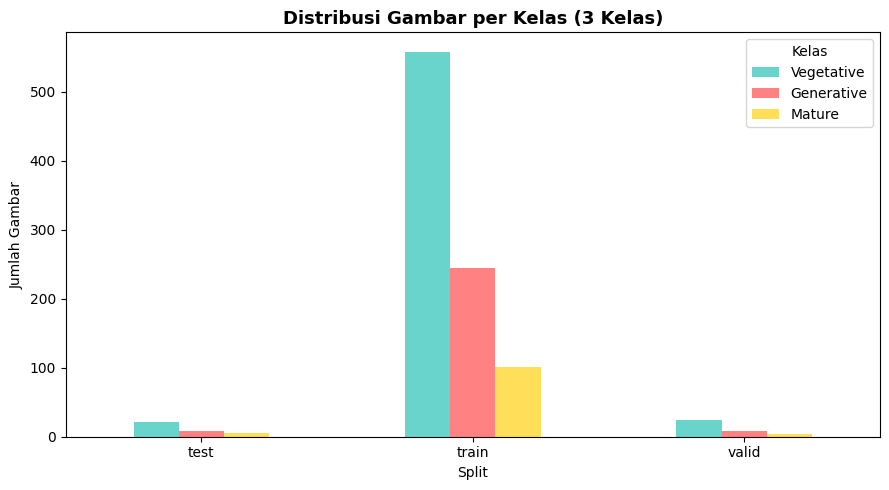

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Bar chart distribusi per split
fig, ax = plt.subplots(figsize=(9, 5))
counts.plot(kind="bar", ax=ax, color=["#4ECDC4","#FF6B6B","#FFD93D"], alpha=0.85)
ax.set_title("Distribusi Gambar per Kelas (3 Kelas)", fontsize=13, fontweight="bold")
ax.set_xlabel("Split")
ax.set_ylabel("Jumlah Gambar")
ax.legend(title="Kelas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


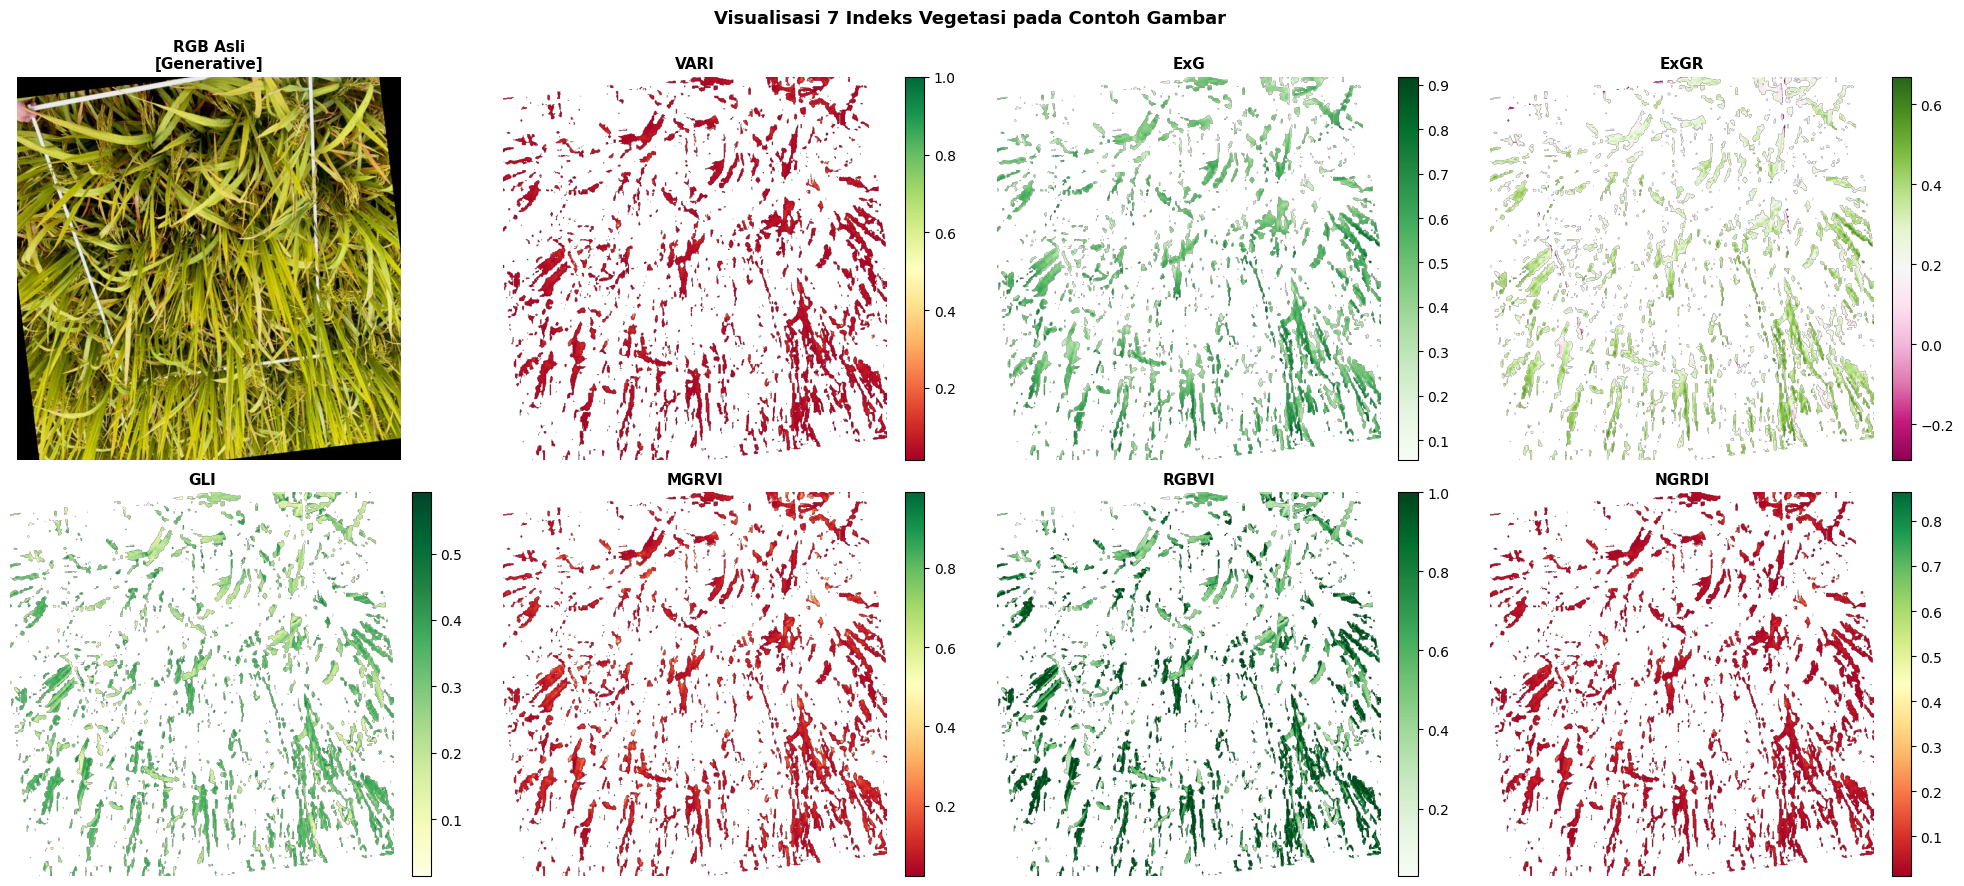

In [12]:
# Visualisasi 7 VI pada satu contoh gambar
example_path = df_all[df_all["split"]=="train"]["path"].iloc[10]
rgb  = read_rgb(example_path)
mask = green_mask(rgb)
label_ex = df_all[df_all["path"]==example_path]["label"].values[0]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

axes[0].imshow(rgb)
axes[0].set_title(f"RGB Asli\n[{label_ex}]", fontweight="bold", fontsize=11)
axes[0].axis("off")

cmaps = ["RdYlGn","Greens","PiYG","YlGn","RdYlGn","Greens","RdYlGn"]
for i, (vi_name, vi_fn) in enumerate(VI_REGISTRY.items()):
    vi_map    = vi_fn(rgb).astype(float)
    vi_masked = vi_map.copy()
    vi_masked[~mask] = np.nan
    im = axes[i+1].imshow(vi_masked, cmap=cmaps[i])
    axes[i+1].set_title(vi_name, fontweight="bold", fontsize=11)
    axes[i+1].axis("off")
    plt.colorbar(im, ax=axes[i+1], fraction=0.046, pad=0.04)

plt.suptitle("Visualisasi 7 Indeks Vegetasi pada Contoh Gambar", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Distribusi Fitur Mean per Kelas (3 Kelas)

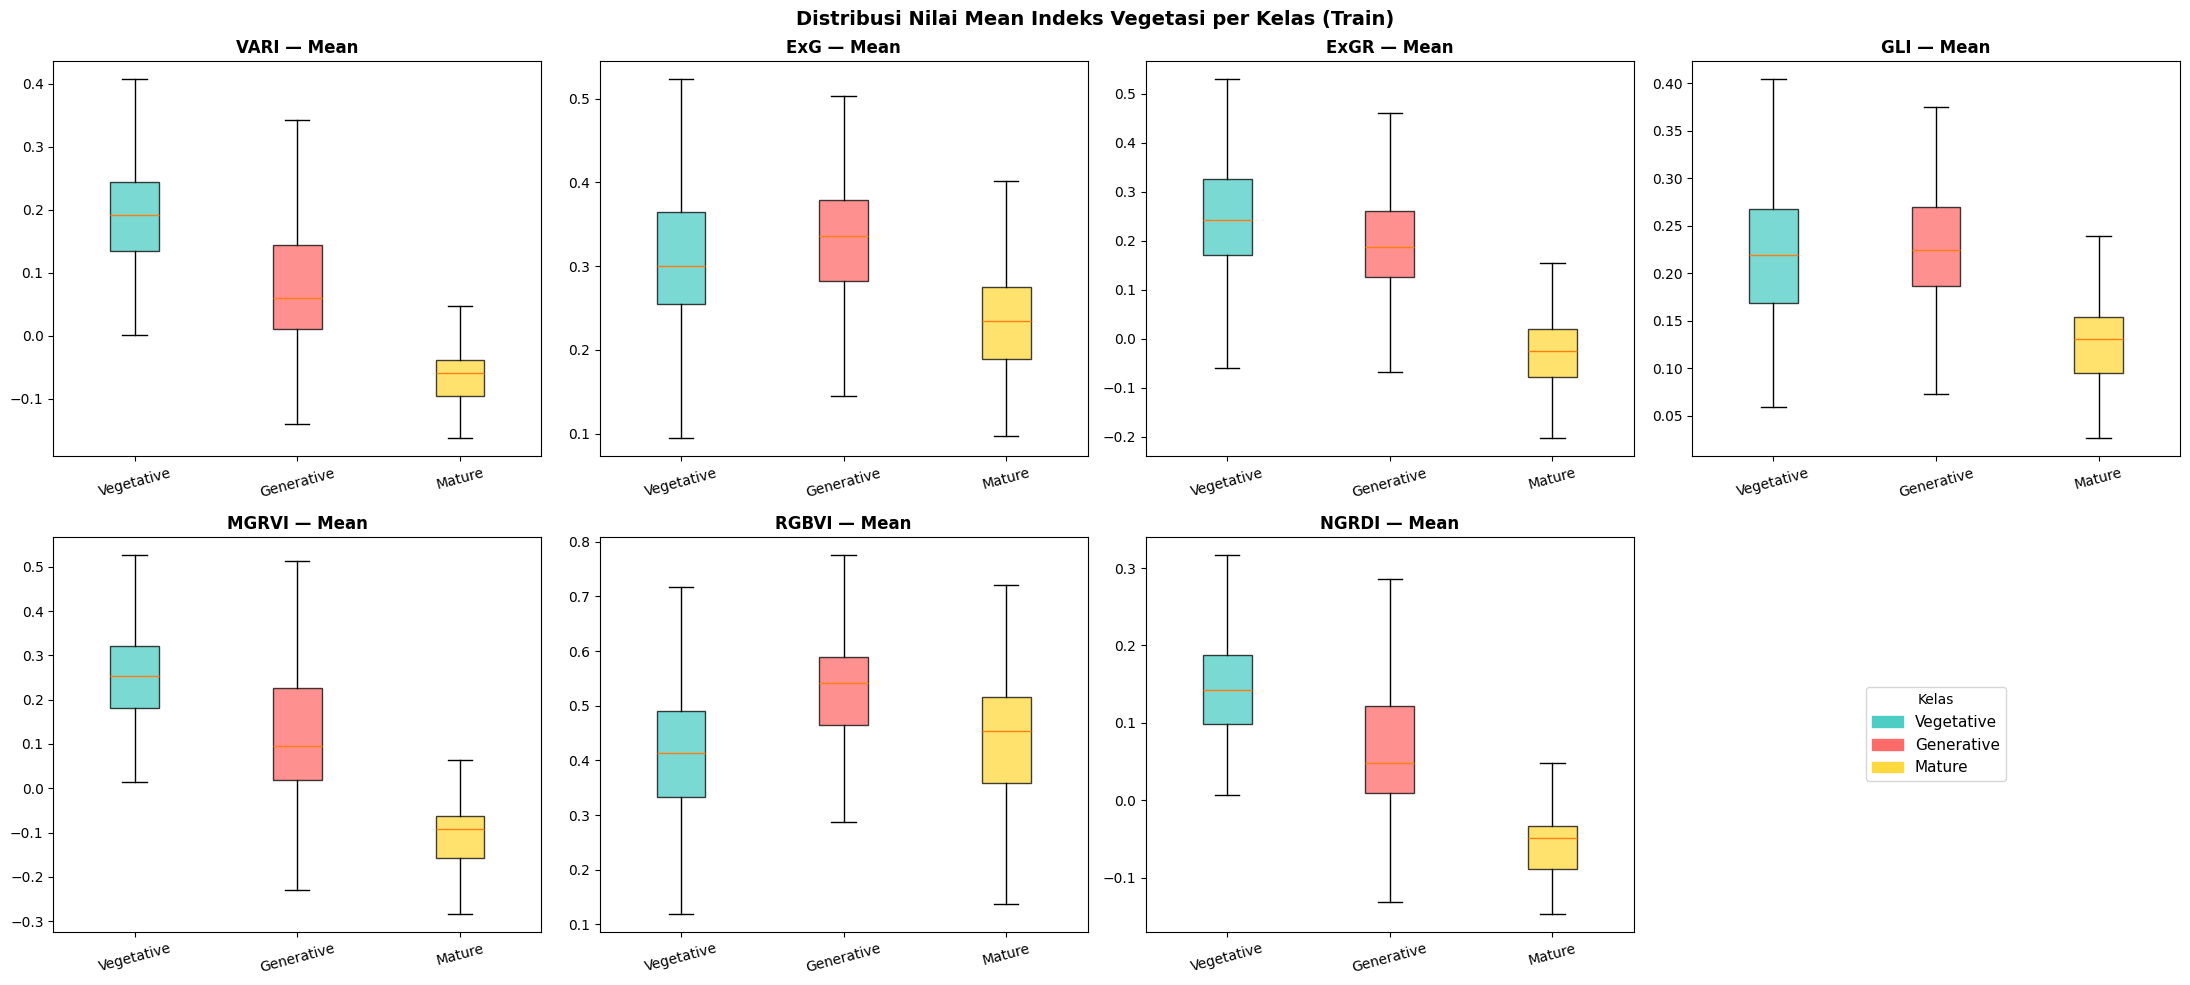

In [13]:
train_sub = df_all[df_all["split"]=="train"].copy()
vi_names  = list(VI_REGISTRY.keys())
colors3   = ["#4ECDC4","#FF6B6B","#FFD93D"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, vi in enumerate(vi_names):
    col  = f"{vi}_mean"
    data = [train_sub[train_sub["label"]==cls][col].values for cls in CLASS_ORDER]
    bp   = axes[i].boxplot(data, labels=CLASS_ORDER, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], colors3):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axes[i].set_title(f"{vi} — Mean", fontweight="bold")
    axes[i].tick_params(axis='x', rotation=15)

axes[-1].axis("off")
legend_patches = [mpatches.Patch(color=c, label=cls) for c, cls in zip(colors3, CLASS_ORDER)]
axes[-1].legend(handles=legend_patches, loc="center", fontsize=11, title="Kelas")

plt.suptitle("Distribusi Nilai Mean Indeks Vegetasi per Kelas (Train)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Korelasi Antar Indeks Vegetasi

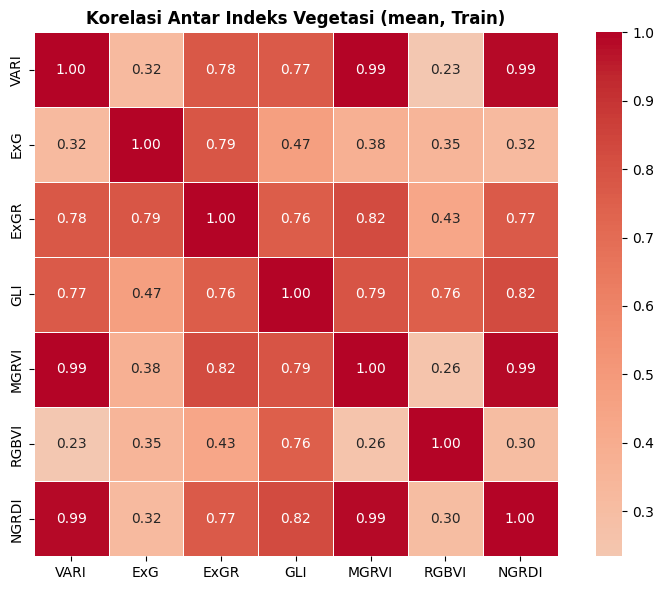

In [14]:
import seaborn as sns

mean_cols = [f"{vi}_mean" for vi in vi_names]
corr = train_sub[mean_cols].rename(columns={f"{v}_mean": v for v in vi_names}).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Korelasi Antar Indeks Vegetasi (mean, Train)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 🧪 Eksperimen: 7 VI × 5 Model (3 Kelas)

Pipeline setiap kombinasi:
1. Ambil fitur VI terpilih + GLCM (18 fitur per kombinasi)
2. **5-Fold Stratified CV** dengan `ImbPipeline`:
   - `RandomOverSampler` hanya aktif pada **fold training** — fold validasi tetap data asli
   - Mencegah *data leakage* yang menggelembungkan skor CV
3. Model akhir: ROS pada seluruh `trainval` → latih → evaluasi `test set`
4. Metrik utama: **F1-Macro** (robust terhadap class imbalance)

> ⚠️ **Catatan Label Encoding**: `LabelEncoder` mengurutkan secara alfabet →
> Generative=0, Mature=1, Vegetative=2. Semua output (`classification_report`,
> `ConfusionMatrixDisplay`) menggunakan `le.classes_` agar label benar.


In [15]:
# Label encoding
le = LabelEncoder()
le.fit(CLASS_ORDER)
df_all["y"] = le.transform(df_all["label"])
print("Classes:", list(le.classes_))
print("Encoding:", {c: le.transform([c])[0] for c in CLASS_ORDER})

# Split
train_df    = df_all[df_all["split"]=="train"].copy()
val_df      = df_all[df_all["split"]=="valid"].copy()
test_df     = df_all[df_all["split"]=="test"].copy()

# Gabungkan train+val untuk CV
trainval_df = pd.concat([train_df, val_df], ignore_index=True)

y_trainval  = trainval_df["y"].values
y_test      = test_df["y"].values

print(f"\nTrain+Val (untuk CV): {len(trainval_df)} gambar")
print(f"Test (final check)  : {len(test_df)} gambar")
print(f"\nDistribusi Train+Val: {dict(zip(le.classes_, np.bincount(y_trainval)))}")
print(f"Distribusi Test     : {dict(zip(le.classes_, np.bincount(y_test)))}")


Classes: [np.str_('Generative'), np.str_('Mature'), np.str_('Vegetative')]
Encoding: {'Vegetative': np.int64(2), 'Generative': np.int64(0), 'Mature': np.int64(1)}

Train+Val (untuk CV): 940 gambar
Test (final check)  : 35 gambar

Distribusi Train+Val: {np.str_('Generative'): np.int64(253), np.str_('Mature'): np.int64(105), np.str_('Vegetative'): np.int64(582)}
Distribusi Test     : {np.str_('Generative'): np.int64(8), np.str_('Mature'): np.int64(5), np.str_('Vegetative'): np.int64(22)}


In [16]:
def get_models():
    """Model biasa — dipakai untuk prediksi final setelah training."""
    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"
        ),
        "SVM_RBF": Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", C=5, gamma="scale",
                        class_weight="balanced", random_state=42, probability=True))
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=7))
        ]),
        "LogReg": Pipeline([
            ("scaler", StandardScaler()),
            ("lr", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
        ]),
        "GradBoost": GradientBoostingClassifier(n_estimators=200, random_state=42),
    }

from imblearn.pipeline import Pipeline as ImbPipeline

def get_models_with_ros():
    """
    Model dengan ROS di dalam pipeline — dipakai untuk CV.
    ROS hanya diterapkan pada fold TRAIN di tiap fold,
    fold TEST tetap data asli → CV score lebih jujur, tidak overfitting.
    """
    return {
        "RandomForest": ImbPipeline([
            ("ros", RandomOverSampler(random_state=42)),
            ("clf", RandomForestClassifier(
                n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"))
        ]),
        "SVM_RBF": ImbPipeline([
            ("ros",    RandomOverSampler(random_state=42)),
            ("scaler", StandardScaler()),
            ("clf",    SVC(kernel="rbf", C=5, gamma="scale",
                           class_weight="balanced", random_state=42, probability=True))
        ]),
        "KNN": ImbPipeline([
            ("ros",    RandomOverSampler(random_state=42)),
            ("scaler", StandardScaler()),
            ("clf",    KNeighborsClassifier(n_neighbors=7))
        ]),
        "LogReg": ImbPipeline([
            ("ros",    RandomOverSampler(random_state=42)),
            ("scaler", StandardScaler()),
            ("clf",    LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
        ]),
        "GradBoost": ImbPipeline([
            ("ros", RandomOverSampler(random_state=42)),
            ("clf", GradientBoostingClassifier(n_estimators=200, random_state=42))
        ]),
    }

MODEL_NAMES = list(get_models().keys())
VI_NAMES    = list(VI_REGISTRY.keys())
STAT_NAMES  = list(extract_vi_stats(np.array([0])).keys())
GLCM_NAMES  = [f'glcm_{p}_{s}' for p in ['contrast','correlation','energy','homogeneity']
                for s in ['mean','std']]

print(f"Model : {MODEL_NAMES}")
print(f"VI    : {VI_NAMES}")
print(f"Total kombinasi: {len(VI_NAMES)} × {len(MODEL_NAMES)} = {len(VI_NAMES)*len(MODEL_NAMES)}")
print("\n✅ get_models_with_ros() siap — ROS ada di dalam pipeline CV")


Model : ['RandomForest', 'SVM_RBF', 'KNN', 'LogReg', 'GradBoost']
VI    : ['VARI', 'ExG', 'ExGR', 'GLI', 'MGRVI', 'RGBVI', 'NGRDI']
Total kombinasi: 7 × 5 = 35

✅ get_models_with_ros() siap — ROS ada di dalam pipeline CV


### Jalankan Eksperimen (CV sebagai metrik utama)

In [17]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
exp_results = []

for vi_name in VI_NAMES:
    vi_feat_cols  = [f"{vi_name}_{s}" for s in STAT_NAMES] + GLCM_NAMES

    X_trainval_vi = trainval_df[vi_feat_cols].values  # data ASLI, tanpa ROS dulu
    X_test_vi     = test_df[vi_feat_cols].values

    print(f"\n{'='*55}")
    print(f"  VI: {vi_name}  ({len(vi_feat_cols)} fitur)")
    print(f"  TrainVal asli: {dict(zip(le.classes_, np.bincount(y_trainval)))}")
    print(f"{'='*55}")

    for model_name, pipe_cv in get_models_with_ros().items():
        # ── CV pakai pipeline (ROS di dalam fold train) ───────────────────
        cv_scores = cross_validate(
            pipe_cv, X_trainval_vi, y_trainval, cv=skf,
            scoring=["accuracy", "f1_macro", "f1_weighted"], n_jobs=-1
        )
        cv_acc     = cv_scores["test_accuracy"].mean()
        cv_acc_std = cv_scores["test_accuracy"].std()
        cv_f1      = cv_scores["test_f1_macro"].mean()
        cv_f1_std  = cv_scores["test_f1_macro"].std()
        cv_f1w     = cv_scores["test_f1_weighted"].mean()

        # ── Final training: ROS manual lalu fit model biasa ───────────────
        ros_final = RandomOverSampler(random_state=42)
        X_tv_sm, y_tv_sm = ros_final.fit_resample(X_trainval_vi, y_trainval)
        clf_final = get_models()[model_name]
        clf_final.fit(X_tv_sm, y_tv_sm)

        # ── Evaluasi test set ─────────────────────────────────────────────
        test_pred = clf_final.predict(X_test_vi)
        test_acc  = accuracy_score(y_test, test_pred)
        test_f1   = f1_score(y_test, test_pred, average="macro")
        test_f1w  = f1_score(y_test, test_pred, average="weighted")

        exp_results.append({
            "vi":               vi_name,
            "model":            model_name,
            "cv_acc":           round(cv_acc, 4),
            "cv_acc_std":       round(cv_acc_std, 4),
            "cv_f1_macro":      round(cv_f1, 4),
            "cv_f1_std":        round(cv_f1_std, 4),
            "cv_f1_weighted":   round(cv_f1w, 4),
            "test_acc":         round(test_acc, 4),
            "test_f1_macro":    round(test_f1, 4),
            "test_f1_weighted": round(test_f1w, 4),
        })

        print(f"  {model_name:15s}  "
              f"CV_acc={cv_acc:.4f}±{cv_acc_std:.4f}  "
              f"CV_F1={cv_f1:.4f}±{cv_f1_std:.4f}  "
              f"test_acc={test_acc:.4f}")

exp_df = pd.DataFrame(exp_results)
print(f"\n✅ Eksperimen selesai. Total kombinasi: {len(exp_df)}")



  VI: VARI  (18 fitur)
  TrainVal asli: {np.str_('Generative'): np.int64(253), np.str_('Mature'): np.int64(105), np.str_('Vegetative'): np.int64(582)}
  RandomForest     CV_acc=0.8862±0.0327  CV_F1=0.8560±0.0403  test_acc=0.9429
  SVM_RBF          CV_acc=0.8968±0.0291  CV_F1=0.8603±0.0393  test_acc=0.9714
  KNN              CV_acc=0.8362±0.0264  CV_F1=0.7949±0.0243  test_acc=0.9429
  LogReg           CV_acc=0.8713±0.0246  CV_F1=0.8421±0.0463  test_acc=0.9143
  GradBoost        CV_acc=0.8968±0.0341  CV_F1=0.8701±0.0431  test_acc=0.9429

  VI: ExG  (18 fitur)
  TrainVal asli: {np.str_('Generative'): np.int64(253), np.str_('Mature'): np.int64(105), np.str_('Vegetative'): np.int64(582)}
  RandomForest     CV_acc=0.8968±0.0225  CV_F1=0.8534±0.0411  test_acc=0.9143
  SVM_RBF          CV_acc=0.9170±0.0244  CV_F1=0.8721±0.0417  test_acc=0.9143
  KNN              CV_acc=0.8755±0.0201  CV_F1=0.8303±0.0294  test_acc=0.8571
  LogReg           CV_acc=0.8968±0.0192  CV_F1=0.8543±0.0321  test_acc=0.

## 📋 Tabel Hasil & Ranking

In [18]:
# Harmonic mean CV-Test sebagai ukuran konsistensi model
exp_df["cv_test_hmean"] = (
    2 * exp_df["cv_f1_macro"] * exp_df["test_f1_macro"]
    / (exp_df["cv_f1_macro"] + exp_df["test_f1_macro"] + 1e-9)
).round(4)

# Ranking 1: CV F1-Macro (metrik statistik utama)
exp_df_sorted = exp_df.sort_values("cv_f1_macro", ascending=False).reset_index(drop=True)
exp_df_sorted.index += 1

print("=== TOP 10 — Ranking CV F1-Macro (Metrik Statistik Utama) ===")
display(exp_df_sorted[["vi","model","cv_acc","cv_acc_std",
                        "cv_f1_macro","cv_f1_std","test_acc","test_f1_macro",
                        "cv_test_hmean"]].head(10))

# Ranking 2: Harmonic mean CV↔Test (rekomendasi praktis / IoT)
exp_df_practical = exp_df.sort_values("cv_test_hmean", ascending=False).reset_index(drop=True)
exp_df_practical.index += 1

print("\n=== TOP 10 — Ranking Harmonic Mean CV↔Test F1 (Rekomendasi Praktis / IoT) ===")
print("(Model yang konsisten di CV maupun test set — penting untuk deployment)")
display(exp_df_practical[["vi","model","cv_f1_macro","test_f1_macro","cv_test_hmean"]].head(10))

EXP_CSV = "/content/experiment_3class_results.csv"
exp_df_sorted.to_csv(EXP_CSV, index=True)
print(f"\nSaved: {EXP_CSV}")


=== TOP 10 — Ranking CV F1-Macro (Metrik Statistik Utama) ===


,vi,model,cv_acc,cv_acc_std,cv_f1_macro,cv_f1_std,test_acc,test_f1_macro,cv_test_hmean
1,ExGR,SVM_RBF,0.9277,0.0302,0.8901,0.0483,0.9714,0.9704,0.9285
2,ExGR,RandomForest,0.9213,0.0123,0.8890,0.0284,0.9429,0.8796,0.8843
3,ExGR,GradBoost,0.9128,0.0268,0.8863,0.0434,0.9143,0.8541,0.8699
4,ExG,SVM_RBF,0.9170,0.0244,0.8721,0.0417,0.9143,0.8424,0.8570
5,ExGR,LogReg,0.9064,0.0325,0.8710,0.0473,0.8857,0.8341,0.8522
6,VARI,GradBoost,0.8968,0.0341,0.8701,0.0431,0.9429,0.9139,0.8915
7,MGRVI,SVM_RBF,0.9064,0.0313,0.8680,0.0439,0.9714,0.9704,0.9163
8,NGRDI,GradBoost,0.8894,0.0371,0.8660,0.0398,0.9143,0.8890,0.8773
9,GLI,GradBoost,0.9000,0.0250,0.8637,0.0458,0.9429,0.8796,0.8716
10,GLI,SVM_RBF,0.9085,0.0387,0.8636,0.0615,0.9429,0.9139,0.8880



=== TOP 10 — Ranking Harmonic Mean CV↔Test F1 (Rekomendasi Praktis / IoT) ===
(Model yang konsisten di CV maupun test set — penting untuk deployment)


,vi,model,cv_f1_macro,test_f1_macro,cv_test_hmean
1,ExGR,SVM_RBF,0.8901,0.9704,0.9285
2,MGRVI,SVM_RBF,0.8680,0.9704,0.9163
3,NGRDI,SVM_RBF,0.8605,0.9704,0.9122
4,VARI,SVM_RBF,0.8603,0.9704,0.9120
5,RGBVI,SVM_RBF,0.8495,0.9434,0.8940
6,VARI,GradBoost,0.8701,0.9139,0.8915
7,GLI,SVM_RBF,0.8636,0.9139,0.8880
8,NGRDI,RandomForest,0.8597,0.9139,0.8860
9,ExGR,RandomForest,0.8890,0.8796,0.8843
10,VARI,RandomForest,0.8560,0.9139,0.8840



Saved: /content/experiment_3class_results.csv


## 🗺️ Heatmap Performa: VI × Model

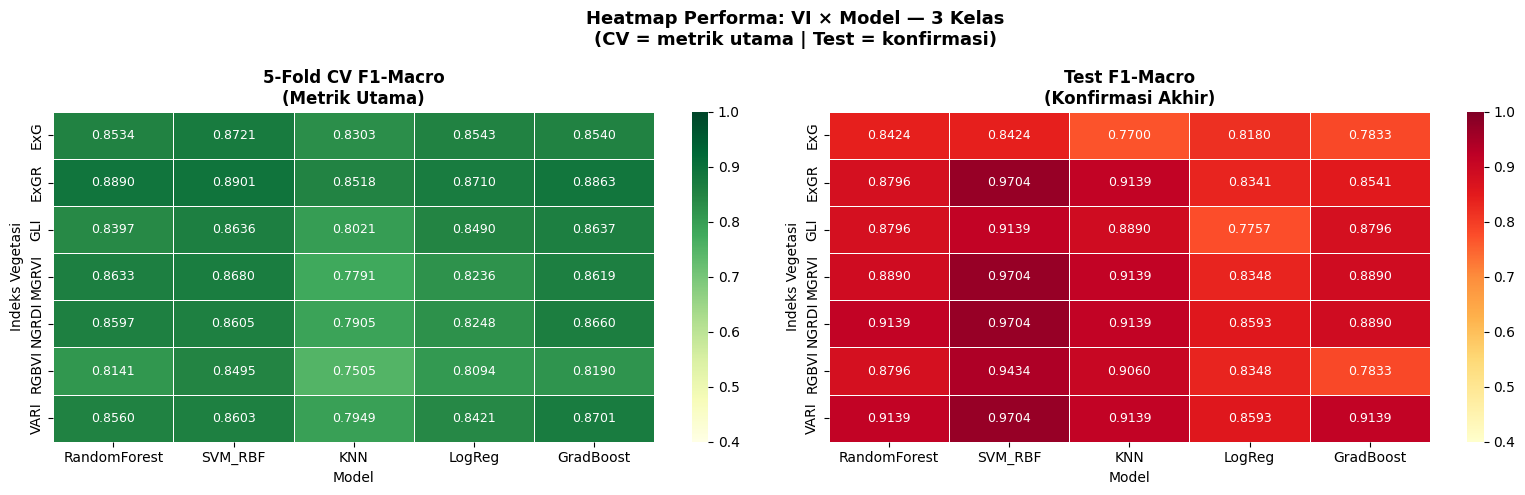

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_cv_f1   = exp_df.pivot(index="vi", columns="model", values="cv_f1_macro")[MODEL_NAMES]
pivot_test_f1 = exp_df.pivot(index="vi", columns="model", values="test_f1_macro")[MODEL_NAMES]

sns.heatmap(pivot_cv_f1, annot=True, fmt=".4f", cmap="YlGn",
            linewidths=0.5, ax=axes[0], vmin=0.4, vmax=1.0, annot_kws={"size":9})
axes[0].set_title("5-Fold CV F1-Macro\n(Metrik Utama)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Indeks Vegetasi")

sns.heatmap(pivot_test_f1, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[1], vmin=0.4, vmax=1.0, annot_kws={"size":9})
axes[1].set_title("Test F1-Macro\n(Konfirmasi Akhir)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Indeks Vegetasi")

plt.suptitle("Heatmap Performa: VI × Model — 3 Kelas\n(CV = metrik utama | Test = konfirmasi)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 📊 Ranking VI dan Model

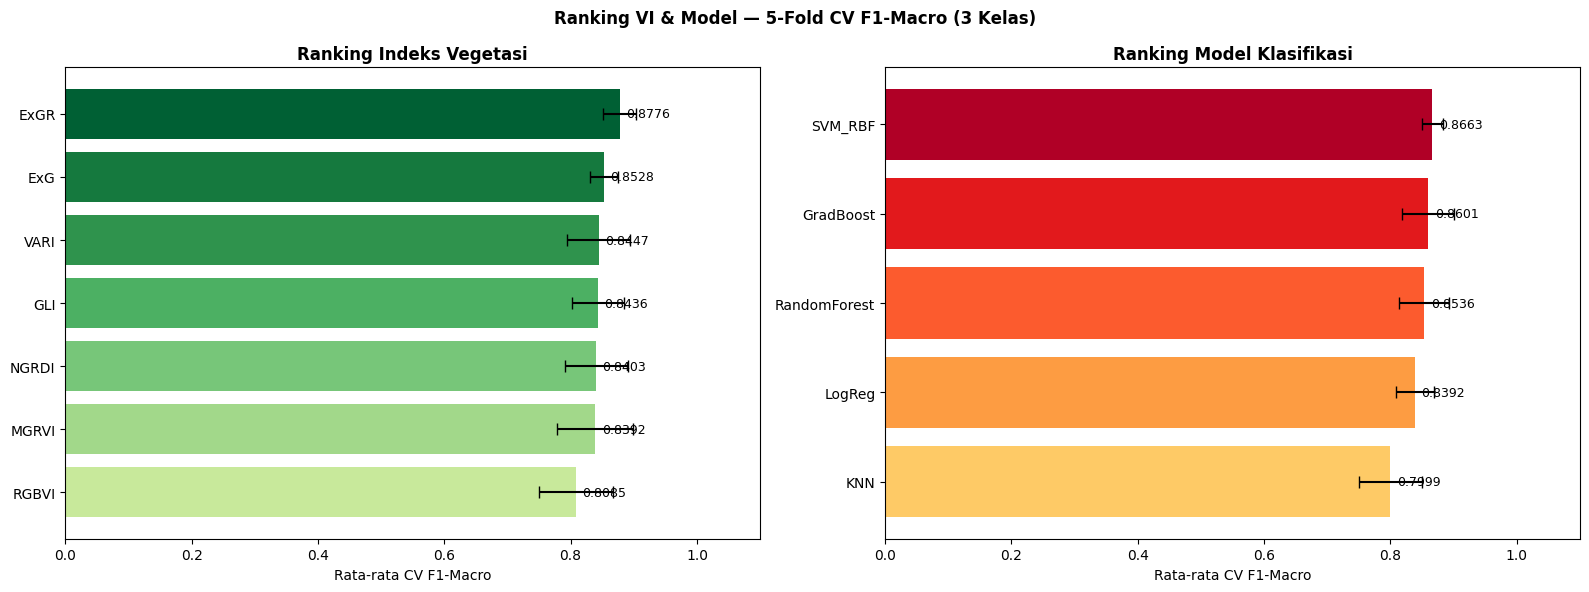

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vi_avg = exp_df.groupby("vi")["cv_f1_macro"].agg(["mean","min"]).reset_index()
vi_avg = vi_avg.sort_values("mean", ascending=True)
colors_vi = plt.cm.YlGn(np.linspace(0.3, 0.9, len(vi_avg)))
bars = axes[0].barh(vi_avg["vi"], vi_avg["mean"], color=colors_vi,
                    xerr=(vi_avg["mean"]-vi_avg["min"]).values, capsize=4)
axes[0].set_xlabel("Rata-rata CV F1-Macro")
axes[0].set_title("Ranking Indeks Vegetasi", fontweight="bold")
axes[0].set_xlim(0, 1.1)
for bar, val in zip(bars, vi_avg["mean"]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)

model_avg = exp_df.groupby("model")["cv_f1_macro"].agg(["mean","min"]).reset_index()
model_avg = model_avg.sort_values("mean", ascending=True)
colors_m  = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(model_avg)))
bars2 = axes[1].barh(model_avg["model"], model_avg["mean"], color=colors_m,
                     xerr=(model_avg["mean"]-model_avg["min"]).values, capsize=4)
axes[1].set_xlabel("Rata-rata CV F1-Macro")
axes[1].set_title("Ranking Model Klasifikasi", fontweight="bold")
axes[1].set_xlim(0, 1.1)
for bar, val in zip(bars2, model_avg["mean"]):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)

plt.suptitle("Ranking VI & Model — 5-Fold CV F1-Macro (3 Kelas)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Grouped Bar: F1 per Model untuk Tiap VI

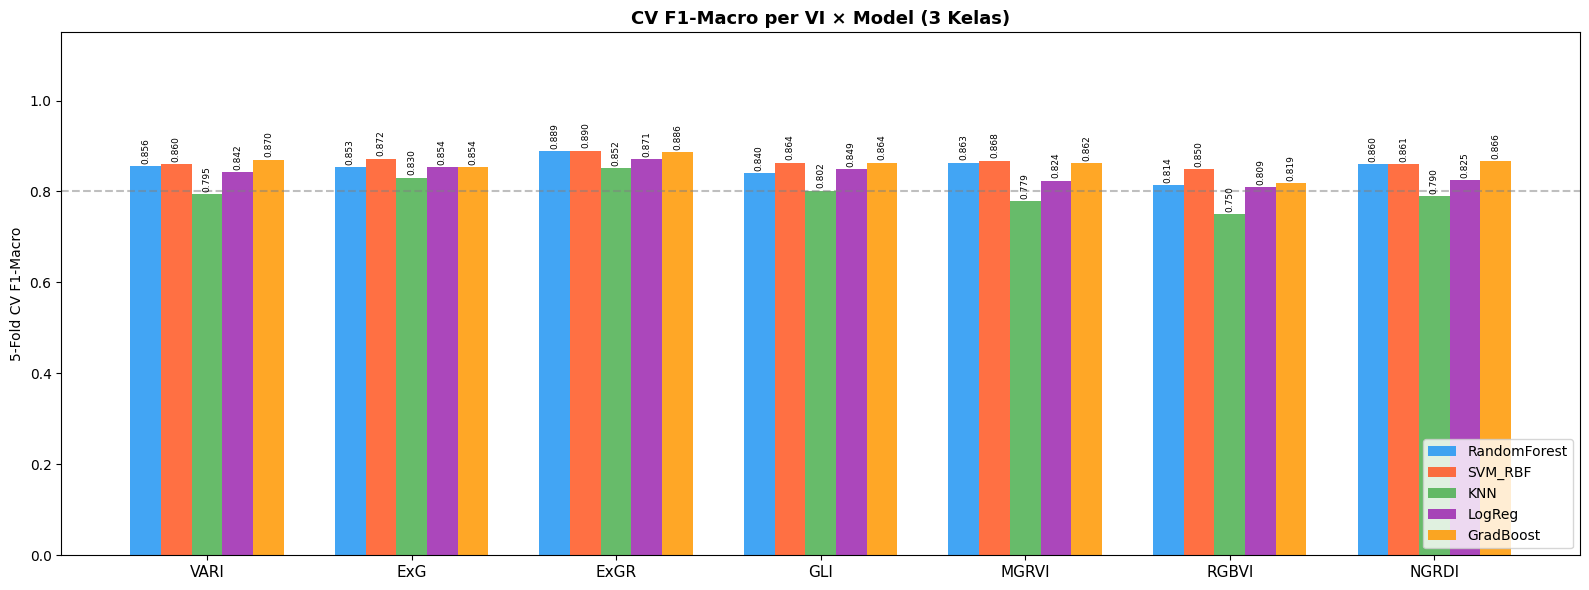

In [21]:
model_colors = {
    "RandomForest": "#2196F3",
    "SVM_RBF":      "#FF5722",
    "KNN":          "#4CAF50",
    "LogReg":       "#9C27B0",
    "GradBoost":    "#FF9800",
}
x     = np.arange(len(VI_NAMES))
width = 0.15
fig, ax = plt.subplots(figsize=(16, 6))

for i, model_name in enumerate(MODEL_NAMES):
    vals = [exp_df[(exp_df["vi"]==vi) & (exp_df["model"]==model_name)]["cv_f1_macro"].values[0]
            for vi in VI_NAMES]
    offset = (i - 2) * width
    rects  = ax.bar(x + offset, vals, width, label=model_name,
                    color=model_colors[model_name], alpha=0.85)
    for rect, v in zip(rects, vals):
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=6.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(VI_NAMES, fontsize=11)
ax.set_ylabel("5-Fold CV F1-Macro")
ax.set_title("CV F1-Macro per VI × Model (3 Kelas)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.15)
ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 🏆 Analisis Mendalam — Kombinasi Terbaik

In [22]:
best_row   = exp_df_sorted.iloc[0]
best_vi    = best_row["vi"]
best_model = best_row["model"]

# Rekomendasi praktis (konsistensi CV-Test, cocok untuk IoT)
practical_row   = exp_df_practical.iloc[0]
prac_vi         = practical_row["vi"]
prac_model      = practical_row["model"]

print(f"🏆 Kombinasi Terbaik secara Statistik (CV F1-Macro tertinggi)")
print(f"   VI      : {best_vi}  |  Model : {best_model}")
print(f"   CV F1   : {best_row['cv_f1_macro']} ± {best_row['cv_f1_std']}")
print(f"   Test F1 : {best_row['test_f1_macro']}  |  HMean CV↔Test : {best_row['cv_test_hmean']}")

print(f"\n📱 Kombinasi Rekomendasi untuk IoT (Harmonic Mean CV↔Test tertinggi)")
print(f"   VI      : {prac_vi}  |  Model : {prac_model}")
print(f"   CV F1   : {practical_row['cv_f1_macro']} ± {practical_row['cv_f1_std']}")
print(f"   Test F1 : {practical_row['test_f1_macro']}  |  HMean CV↔Test : {practical_row['cv_test_hmean']}")

# ── Analisis mendalam: model IoT (konsistensi lebih penting untuk deployment) ──
vi_feat_cols_best = [f"{prac_vi}_{s}" for s in STAT_NAMES] + GLCM_NAMES
X_tv_best = trainval_df[vi_feat_cols_best].values
X_te_best = test_df[vi_feat_cols_best].values

# CV predictions — pipeline (ROS di dalam fold, tidak leakage)
print(f"\n⏳ Menghitung CV predictions: {prac_vi} + {prac_model} ...")
y_cv_pred = cross_val_predict(
    get_models_with_ros()[prac_model],
    X_tv_best, y_trainval, cv=skf, n_jobs=-1
)

# PENTING: gunakan le.classes_ — LabelEncoder sort alfabet (Generative=0,Mature=1,Vegetative=2)
print(f"\n=== Classification Report — 5-Fold CV (n={len(y_trainval)}, data asli) ===")
print(classification_report(y_trainval, y_cv_pred, target_names=list(le.classes_)))

# Final model untuk test
ros_best = RandomOverSampler(random_state=42)
X_tv_sm, y_tv_sm = ros_best.fit_resample(X_tv_best, y_trainval)
best_clf = get_models()[prac_model]
best_clf.fit(X_tv_sm, y_tv_sm)
y_pred_best = best_clf.predict(X_te_best)

print(f"=== Classification Report — Test Set (n={len(y_test)}, konfirmasi) ===")
print(classification_report(y_test, y_pred_best, target_names=list(le.classes_)))

print("\n=== Detail per Fold CV ===")
cv_detail = cross_validate(
    get_models_with_ros()[prac_model], X_tv_best, y_trainval, cv=skf,
    scoring=["accuracy","f1_macro"], n_jobs=-1
)
for i in range(5):
    print(f"  Fold {i+1}: acc={cv_detail['test_accuracy'][i]:.4f}  f1={cv_detail['test_f1_macro'][i]:.4f}")
print(f"  Mean : acc={cv_detail['test_accuracy'].mean():.4f}  f1={cv_detail['test_f1_macro'].mean():.4f}")
print(f"  Std  : acc={cv_detail['test_accuracy'].std():.4f}  f1={cv_detail['test_f1_macro'].std():.4f}")


🏆 Kombinasi Terbaik secara Statistik (CV F1-Macro tertinggi)
   VI      : ExGR  |  Model : SVM_RBF
   CV F1   : 0.8901 ± 0.0483
   Test F1 : 0.9704  |  HMean CV↔Test : 0.9285

📱 Kombinasi Rekomendasi untuk IoT (Harmonic Mean CV↔Test tertinggi)
   VI      : ExGR  |  Model : SVM_RBF
   CV F1   : 0.8901 ± 0.0483
   Test F1 : 0.9704  |  HMean CV↔Test : 0.9285

⏳ Menghitung CV predictions: ExGR + SVM_RBF ...

=== Classification Report — 5-Fold CV (n=940, data asli) ===
              precision    recall  f1-score   support

  Generative       0.90      0.83      0.87       253
      Mature       0.81      0.86      0.83       105
  Vegetative       0.96      0.98      0.97       582

    accuracy                           0.93       940
   macro avg       0.89      0.89      0.89       940
weighted avg       0.93      0.93      0.93       940

=== Classification Report — Test Set (n=35, konfirmasi) ===
              precision    recall  f1-score   support

  Generative       1.00      0.88  

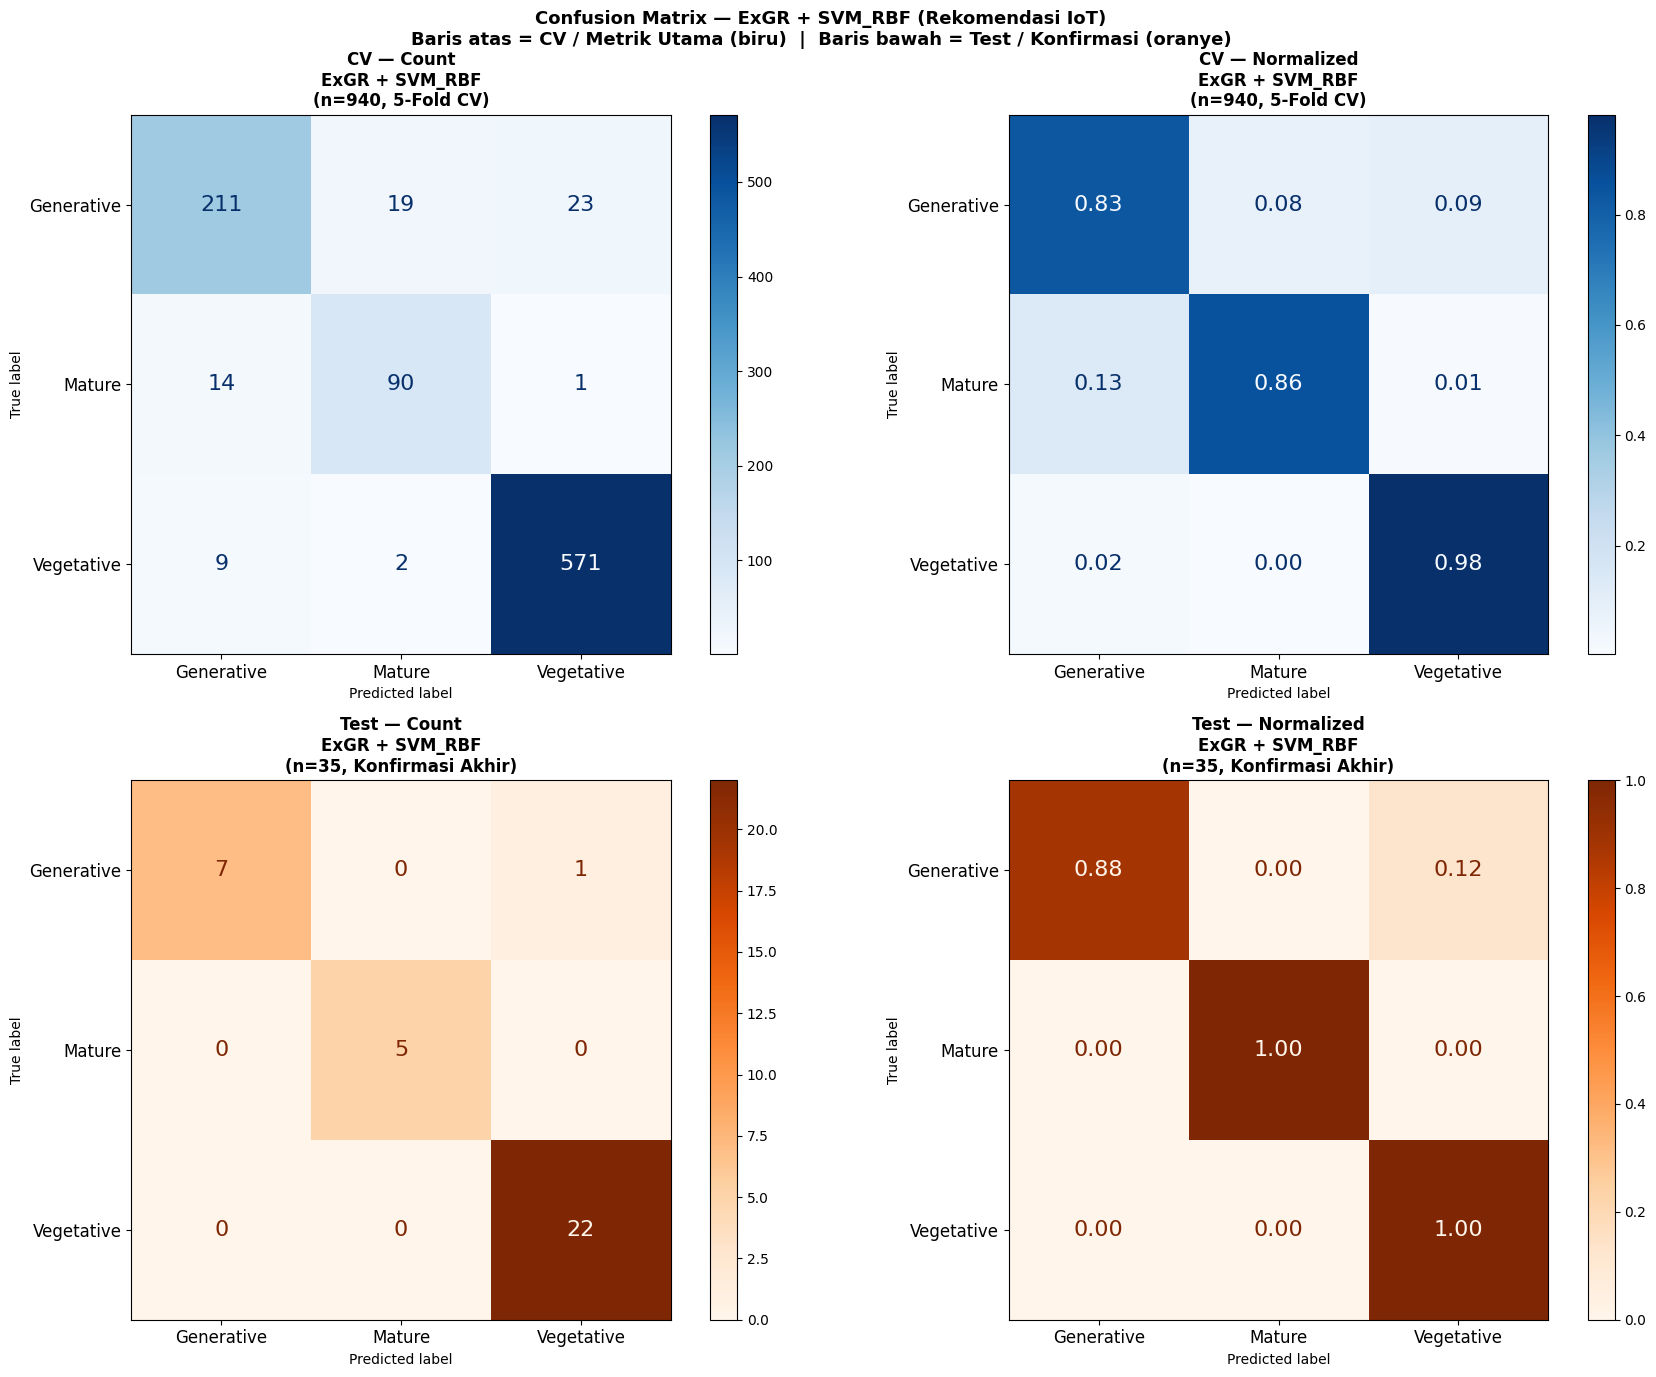

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

# le.classes_ = ['Generative','Mature','Vegetative'] — label benar sesuai encoding
DISP_LABELS = list(le.classes_)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Baris atas: CV (evaluasi utama)
cm_cv      = confusion_matrix(y_trainval, y_cv_pred)
cm_cv_norm = confusion_matrix(y_trainval, y_cv_pred, normalize="true")

disp_cv = ConfusionMatrixDisplay(cm_cv, display_labels=DISP_LABELS)
disp_cv.plot(ax=axes[0][0], colorbar=True, cmap="Blues")
axes[0][0].set_title(
    f"CV — Count\n{prac_vi} + {prac_model}\n(n={len(y_trainval)}, 5-Fold CV)",
    fontweight="bold", fontsize=12)
axes[0][0].tick_params(axis='both', labelsize=12)
for t in disp_cv.text_.ravel(): t.set_fontsize(16)

disp_cv_n = ConfusionMatrixDisplay(cm_cv_norm, display_labels=DISP_LABELS)
disp_cv_n.plot(ax=axes[0][1], colorbar=True, cmap="Blues", values_format=".2f")
axes[0][1].set_title(
    f"CV — Normalized\n{prac_vi} + {prac_model}\n(n={len(y_trainval)}, 5-Fold CV)",
    fontweight="bold", fontsize=12)
axes[0][1].tick_params(axis='both', labelsize=12)
for t in disp_cv_n.text_.ravel(): t.set_fontsize(16)

# Baris bawah: Test (konfirmasi)
cm_test      = confusion_matrix(y_test, y_pred_best)
cm_test_norm = confusion_matrix(y_test, y_pred_best, normalize="true")

disp_te = ConfusionMatrixDisplay(cm_test, display_labels=DISP_LABELS)
disp_te.plot(ax=axes[1][0], colorbar=True, cmap="Oranges")
axes[1][0].set_title(
    f"Test — Count\n{prac_vi} + {prac_model}\n(n={len(y_test)}, Konfirmasi Akhir)",
    fontweight="bold", fontsize=12)
axes[1][0].tick_params(axis='both', labelsize=12)
for t in disp_te.text_.ravel(): t.set_fontsize(16)

disp_te_n = ConfusionMatrixDisplay(cm_test_norm, display_labels=DISP_LABELS)
disp_te_n.plot(ax=axes[1][1], colorbar=True, cmap="Oranges", values_format=".2f")
axes[1][1].set_title(
    f"Test — Normalized\n{prac_vi} + {prac_model}\n(n={len(y_test)}, Konfirmasi Akhir)",
    fontweight="bold", fontsize=12)
axes[1][1].tick_params(axis='both', labelsize=12)
for t in disp_te_n.text_.ravel(): t.set_fontsize(16)

plt.suptitle(
    f"Confusion Matrix — {prac_vi} + {prac_model} (Rekomendasi IoT)\n"
    f"Baris atas = CV / Metrik Utama (biru)  |  Baris bawah = Test / Konfirmasi (oranye)",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Perbandingan Top 3 Kombinasi

Top 3 Kombinasi Terbaik (CV F1-Macro):


,vi,model,cv_f1_macro,cv_f1_std,test_acc,test_f1_macro,cv_test_hmean
1,ExGR,SVM_RBF,0.8901,0.0483,0.9714,0.9704,0.9285
2,ExGR,RandomForest,0.8890,0.0284,0.9429,0.8796,0.8843
3,ExGR,GradBoost,0.8863,0.0434,0.9143,0.8541,0.8699


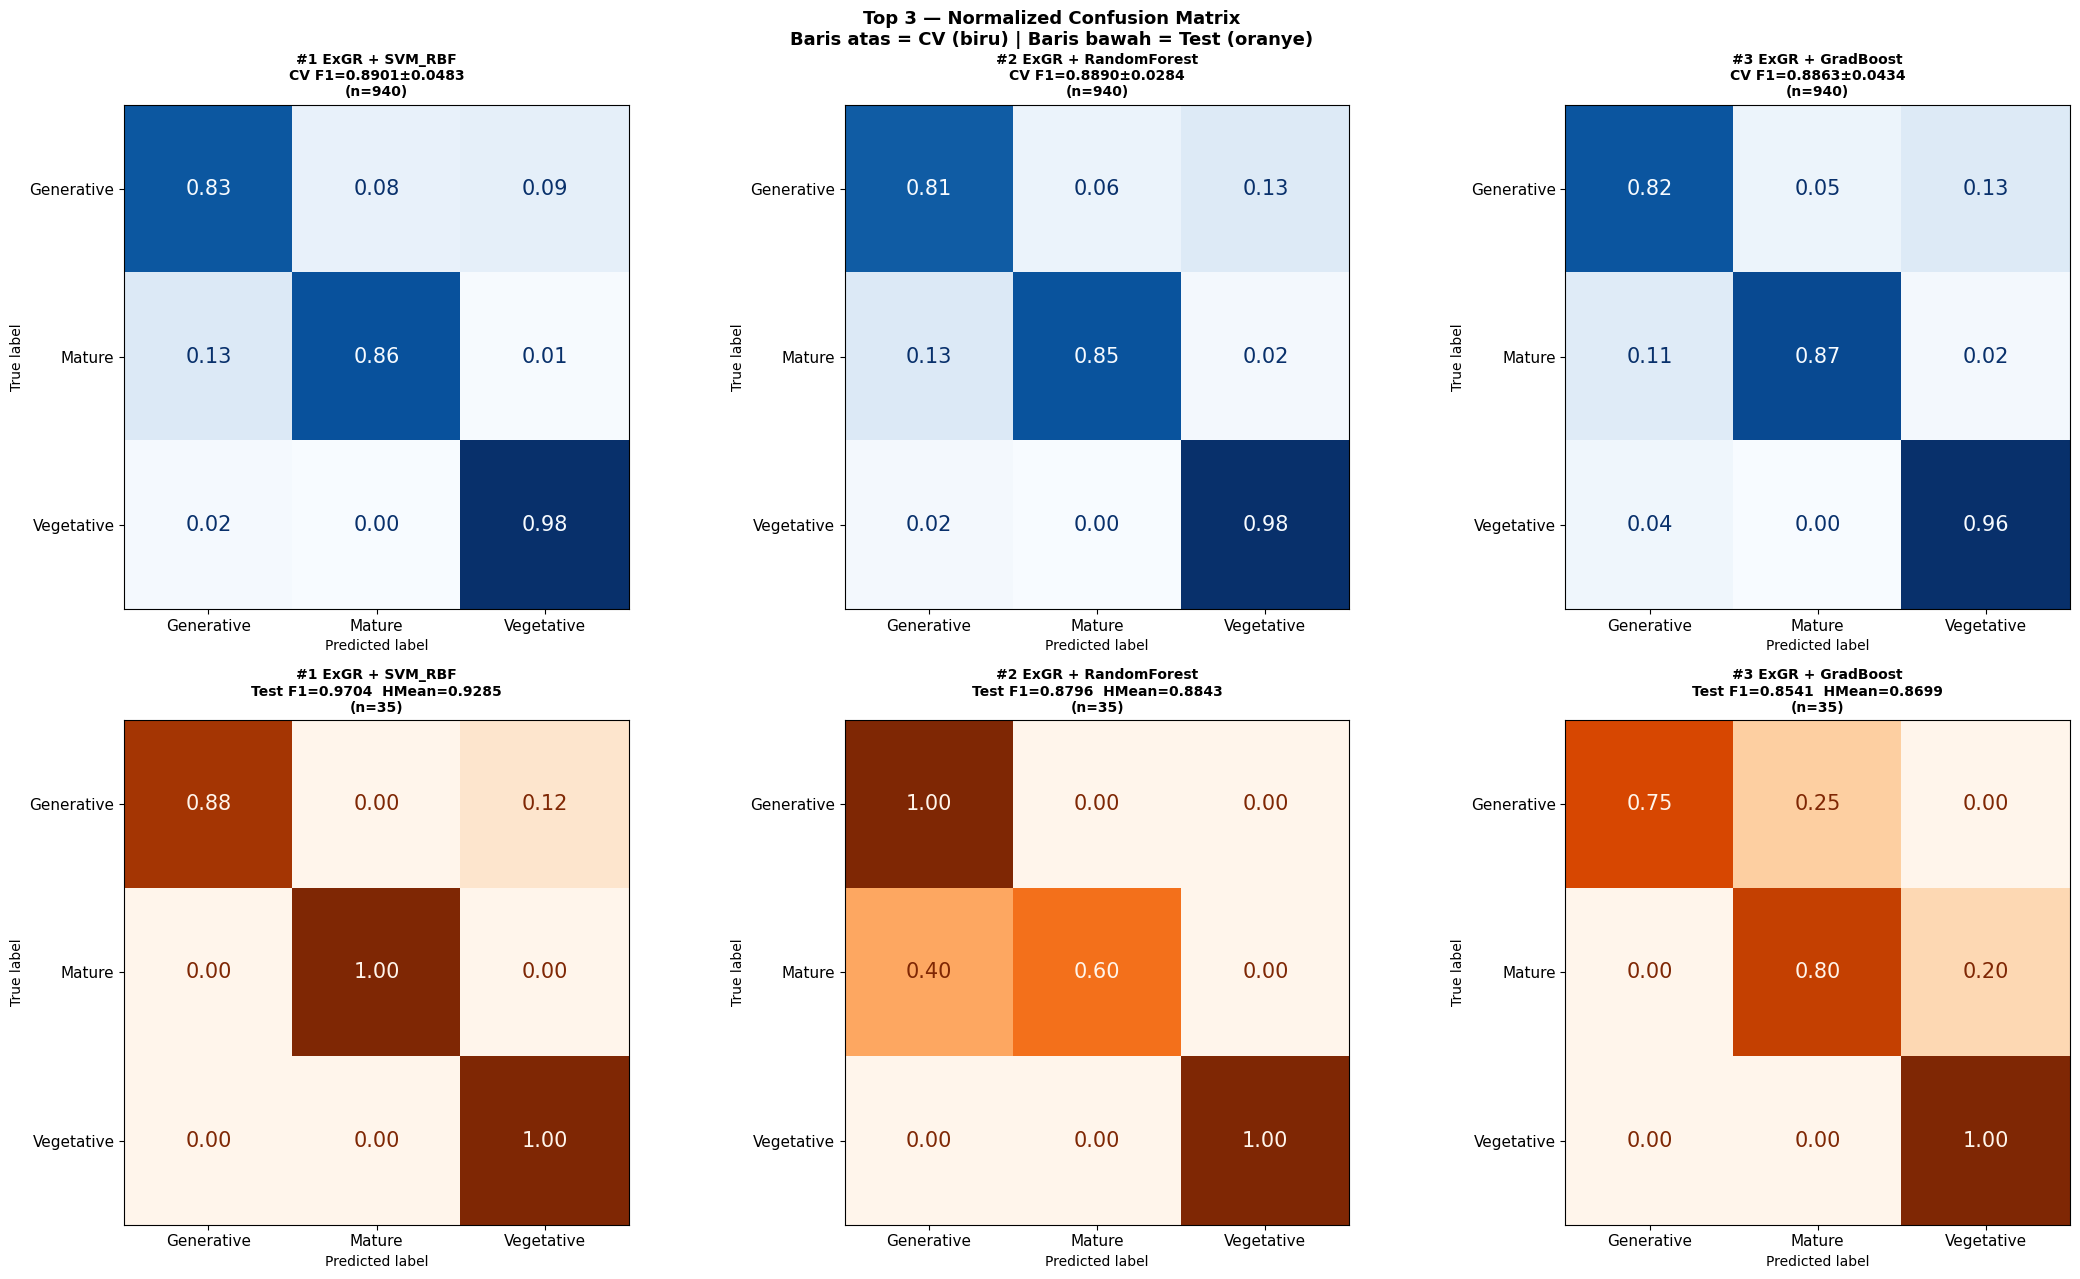

In [24]:
top3 = exp_df_sorted.head(3)
print("Top 3 Kombinasi Terbaik (CV F1-Macro):")
display(top3[["vi","model","cv_f1_macro","cv_f1_std","test_acc","test_f1_macro","cv_test_hmean"]])

DISP_LABELS = list(le.classes_)
fig, axes = plt.subplots(2, 3, figsize=(22, 13))

for idx_plot, (_, row) in enumerate(top3.iterrows()):
    vi      = row["vi"]
    mod     = row["model"]
    vi_cols = [f"{vi}_{s}" for s in STAT_NAMES] + GLCM_NAMES

    X_tv_i = trainval_df[vi_cols].values
    X_te_i = test_df[vi_cols].values

    # CV predictions — pipeline (ROS di dalam fold)
    y_cv_i = cross_val_predict(
        get_models_with_ros()[mod], X_tv_i, y_trainval, cv=skf, n_jobs=-1
    )

    # Final model untuk test
    ros_i = RandomOverSampler(random_state=42)
    X_si, y_si = ros_i.fit_resample(X_tv_i, y_trainval)
    clf_i = get_models()[mod]
    clf_i.fit(X_si, y_si)
    pred_te_i = clf_i.predict(X_te_i)

    # Baris atas: CV
    cm_cv_i = confusion_matrix(y_trainval, y_cv_i, normalize="true")
    disp_cv_i = ConfusionMatrixDisplay(cm_cv_i, display_labels=DISP_LABELS)
    disp_cv_i.plot(ax=axes[0][idx_plot], colorbar=False, cmap="Blues", values_format=".2f")
    axes[0][idx_plot].set_title(
        f"#{idx_plot+1} {vi} + {mod}\nCV F1={row['cv_f1_macro']:.4f}±{row['cv_f1_std']:.4f}\n(n={len(y_trainval)})",
        fontsize=10, fontweight="bold")
    axes[0][idx_plot].tick_params(axis='both', labelsize=11)
    for t in disp_cv_i.text_.ravel(): t.set_fontsize(15)

    # Baris bawah: Test
    cm_te_i = confusion_matrix(y_test, pred_te_i, normalize="true")
    disp_te_i = ConfusionMatrixDisplay(cm_te_i, display_labels=DISP_LABELS)
    disp_te_i.plot(ax=axes[1][idx_plot], colorbar=False, cmap="Oranges", values_format=".2f")
    axes[1][idx_plot].set_title(
        f"#{idx_plot+1} {vi} + {mod}\nTest F1={row['test_f1_macro']:.4f}  HMean={row['cv_test_hmean']:.4f}\n(n={len(y_test)})",
        fontsize=10, fontweight="bold")
    axes[1][idx_plot].tick_params(axis='both', labelsize=11)
    for t in disp_te_i.text_.ravel(): t.set_fontsize(15)

plt.suptitle(
    "Top 3 — Normalized Confusion Matrix\n"
    "Baris atas = CV (biru) | Baris bawah = Test (oranye)",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 🔍 Feature Importance — Kombinasi Terbaik

In [25]:
raw_clf = best_clf.steps[-1][1] if hasattr(best_clf, "steps") else best_clf

if hasattr(raw_clf, "feature_importances_"):
    fi         = raw_clf.feature_importances_
    feat_names = vi_feat_cols_best
    idx_sorted = np.argsort(fi)[::-1]
    top_n      = min(20, len(fi))

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(range(top_n), fi[idx_sorted[:top_n]][::-1],
            color=plt.cm.YlGn(np.linspace(0.3, 0.9, top_n)))
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feat_names[i] for i in idx_sorted[:top_n]][::-1])
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top {top_n} Fitur Terpenting — {best_vi} + {best_model}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("Top 5 fitur:")
    for i in range(5):
        print(f"  {i+1}. {feat_names[idx_sorted[i]]:35s} = {fi[idx_sorted[i]]:.4f}")
else:
    print(f"{best_model} tidak berbasis tree — feature importance tidak tersedia langsung.")


SVM_RBF tidak berbasis tree — feature importance tidak tersedia langsung.


## 🔬 Analisis Misclassification — Kombinasi Terbaik

Salah prediksi : 1 / 35 gambar test
Test Accuracy  : 0.9714

⚠️  Test set kecil (n=35), evaluasi utama dari CV 5-fold

=== Pola Kesalahan ===


,true,pred,count
0,Generative,Vegetative,1


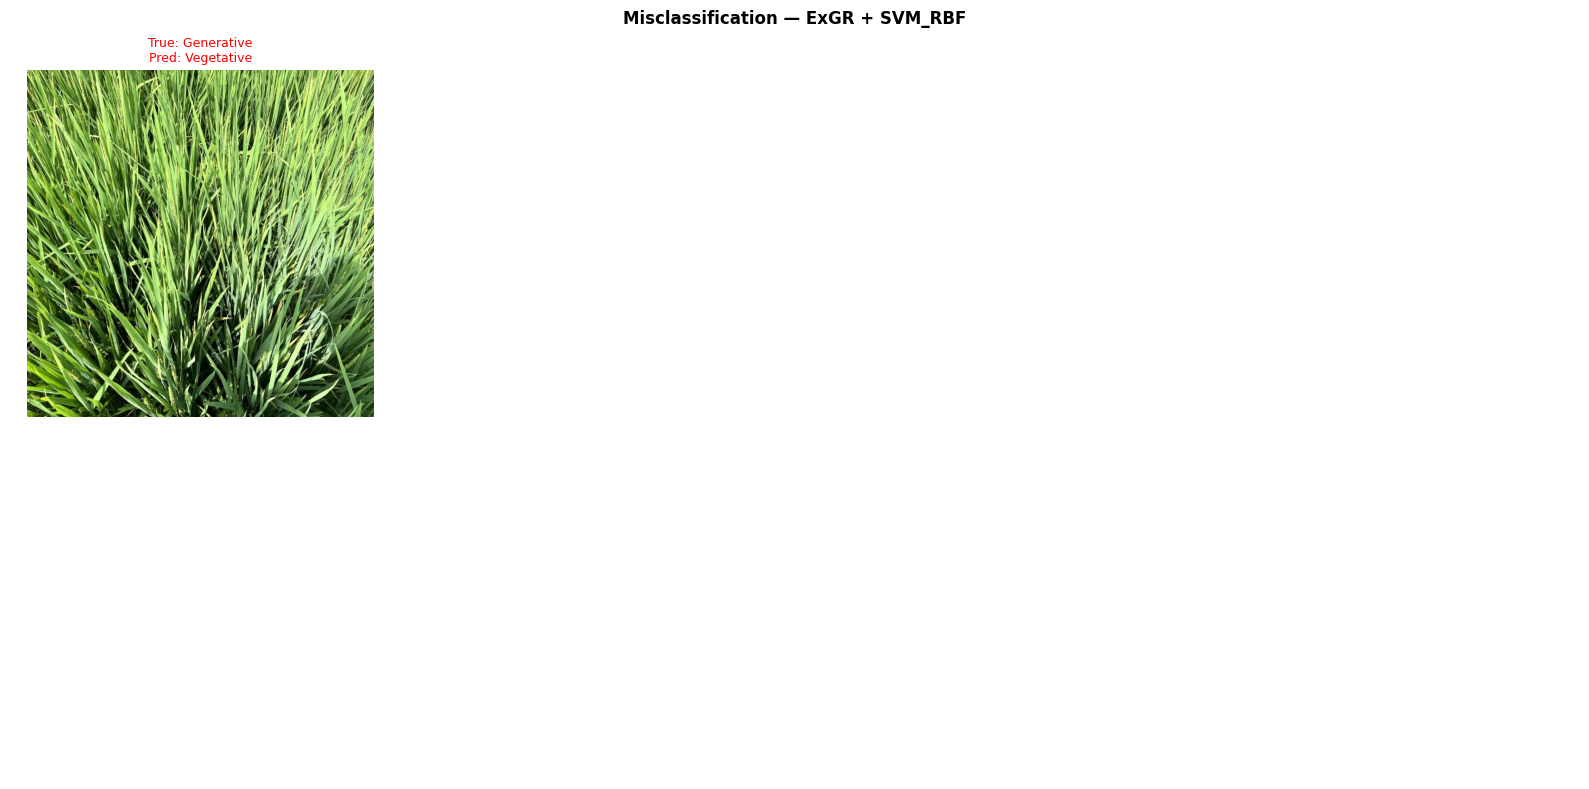

In [26]:
test_df_r = test_df.reset_index(drop=True).copy()
test_df_r["pred"]    = le.inverse_transform(y_pred_best)
test_df_r["true"]    = le.inverse_transform(y_test)
test_df_r["correct"] = test_df_r["pred"] == test_df_r["true"]

wrong = test_df_r[~test_df_r["correct"]].reset_index(drop=True)
print(f"Salah prediksi : {len(wrong)} / {len(test_df_r)} gambar test")
print(f"Test Accuracy  : {test_df_r['correct'].mean():.4f}")
print(f"\n⚠️  Test set kecil (n={len(test_df_r)}), evaluasi utama dari CV 5-fold\n")

if len(wrong) > 0:
    print("=== Pola Kesalahan ===")
    display(wrong.groupby(["true","pred"]).size().reset_index(name="count"))
else:
    print("Tidak ada misclassification pada test set!")

n_show = min(8, len(wrong))
if n_show > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i in range(n_show):
        row = wrong.iloc[i]
        rgb = read_rgb(row["path"])
        if rgb is not None:
            axes[i].imshow(rgb)
        axes[i].set_title(f"True: {row['true']}\nPred: {row['pred']}", fontsize=9, color="red")
        axes[i].axis("off")
    for i in range(n_show, 8):
        axes[i].axis("off")
    plt.suptitle(f"Misclassification — {best_vi} + {best_model}", fontweight="bold")
    plt.tight_layout()
    plt.show()


## 📊 Heatmap CV F1-Macro ± Std per Kombinasi

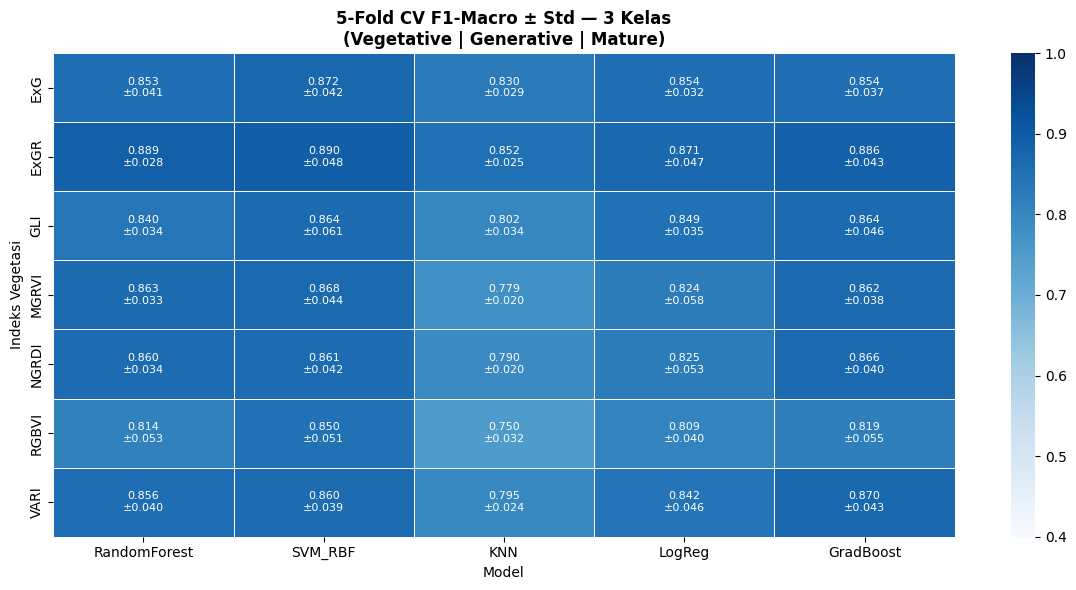

In [27]:
annot_data         = exp_df.copy()
annot_data["label"] = annot_data.apply(
    lambda r: f"{r['cv_f1_macro']:.3f}\n±{r['cv_f1_std']:.3f}", axis=1
)
pivot_annot = annot_data.pivot(index="vi", columns="model", values="label")[MODEL_NAMES]
pivot_val   = exp_df.pivot(index="vi", columns="model", values="cv_f1_macro")[MODEL_NAMES]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_val, annot=pivot_annot, fmt="", cmap="Blues",
            linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0, annot_kws={"size": 8})
ax.set_title("5-Fold CV F1-Macro ± Std — 3 Kelas\n(Vegetative | Generative | Mature)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Indeks Vegetasi")
plt.tight_layout()
plt.show()


## 📝 Ringkasan Eksperimen

In [28]:
print("=" * 65)
print("  RINGKASAN EKSPERIMEN — 3 KELAS")
print("  Vegetative | Generative | Mature")
print("  Metrik utama: 5-Fold Cross-Validation F1-Macro")
print("=" * 65)

print("\n📊 Rata-rata CV F1-Macro per Indeks Vegetasi:")
vi_rank = exp_df.groupby("vi")["cv_f1_macro"].mean().sort_values(ascending=False)
for i, (vi, f1) in enumerate(vi_rank.items(), 1):
    print(f"  {i}. {vi:8s}: {f1:.4f}")

print("\n🤖 Rata-rata CV F1-Macro per Model:")
model_rank = exp_df.groupby("model")["cv_f1_macro"].mean().sort_values(ascending=False)
for i, (m, f1) in enumerate(model_rank.items(), 1):
    print(f"  {i}. {m:15s}: {f1:.4f}")

best = exp_df_sorted.iloc[0]
print(f"\n🏆 Kombinasi Terbaik:")
print(f"   Indeks Vegetasi  : {best['vi']}")
print(f"   Model            : {best['model']}")
print(f"   CV F1-Macro      : {best['cv_f1_macro']} ± {best['cv_f1_std']}")
print(f"   CV Accuracy      : {best['cv_acc']} ± {best['cv_acc_std']}")
print(f"   CV F1-Weighted   : {best['cv_f1_weighted']}")
print(f"   ─────────────────────────────────────────")
print(f"   Test F1-Macro    : {best['test_f1_macro']}  (konfirmasi, n={len(test_df)})")
print(f"   Test Accuracy    : {best['test_acc']}")
print("=" * 65)
print(f"\n⚠️  Catatan: dataset kecil (n={len(df_all)}), test set hanya {len(test_df)} gambar.")
print("   5-Fold CV lebih reliable sebagai estimasi performa generalisasi.")


  RINGKASAN EKSPERIMEN — 3 KELAS
  Vegetative | Generative | Mature
  Metrik utama: 5-Fold Cross-Validation F1-Macro

📊 Rata-rata CV F1-Macro per Indeks Vegetasi:
  1. ExGR    : 0.8776
  2. ExG     : 0.8528
  3. VARI    : 0.8447
  4. GLI     : 0.8436
  5. NGRDI   : 0.8403
  6. MGRVI   : 0.8392
  7. RGBVI   : 0.8085

🤖 Rata-rata CV F1-Macro per Model:
  1. SVM_RBF        : 0.8663
  2. GradBoost      : 0.8601
  3. RandomForest   : 0.8536
  4. LogReg         : 0.8392
  5. KNN            : 0.7999

🏆 Kombinasi Terbaik:
   Indeks Vegetasi  : ExGR
   Model            : SVM_RBF
   CV F1-Macro      : 0.8901 ± 0.0483
   CV Accuracy      : 0.9277 ± 0.0302
   CV F1-Weighted   : 0.9271
   ─────────────────────────────────────────
   Test F1-Macro    : 0.9704  (konfirmasi, n=35)
   Test Accuracy    : 0.9714

⚠️  Catatan: dataset kecil (n=975), test set hanya 35 gambar.
   5-Fold CV lebih reliable sebagai estimasi performa generalisasi.


## 📡 Analisis Khusus IoT — Deteksi Kesiapan Panen

Untuk perangkat IoT berbasis ESP32 + kamera, metrik yang paling kritis adalah:

| Metrik | Alasan |
|--------|--------|
| **Recall kelas Mature** | Jangan sampai padi matang **tidak terdeteksi** (false negative = kerugian panen) |
| **Konsistensi CV↔Test** | Model harus stabil di kondisi lapangan yang beragam |
| **Kesederhanaan model** | Fitur VI + statistik ringan, kompatibel dengan server ringan di edge/cloud |

> Pipeline IoT: ESP32-CAM ambil foto → kirim ke server (Flask/FastAPI) →
> hitung VI + statistik → prediksi model → kirim notifikasi ke petani.


  ANALISIS IoT — RECALL KELAS MATURE (Kritis untuk Panen)

Top 10 — Recall Mature tertinggi (IoT harvest detection):


,vi,model,recall_mature,cv_f1_macro,test_f1_macro,cv_test_hmean
1,ExGR,SVM_RBF,1.0,0.8901,0.9704,0.9285
2,MGRVI,SVM_RBF,1.0,0.8680,0.9704,0.9163
3,NGRDI,SVM_RBF,1.0,0.8605,0.9704,0.9122
4,VARI,SVM_RBF,1.0,0.8603,0.9704,0.9120
5,RGBVI,SVM_RBF,0.8,0.8495,0.9434,0.8940
6,VARI,GradBoost,0.8,0.8701,0.9139,0.8915
7,GLI,SVM_RBF,0.8,0.8636,0.9139,0.8880
8,NGRDI,RandomForest,0.8,0.8597,0.9139,0.8860
9,VARI,RandomForest,0.8,0.8560,0.9139,0.8840
10,ExGR,KNN,0.8,0.8518,0.9139,0.8818


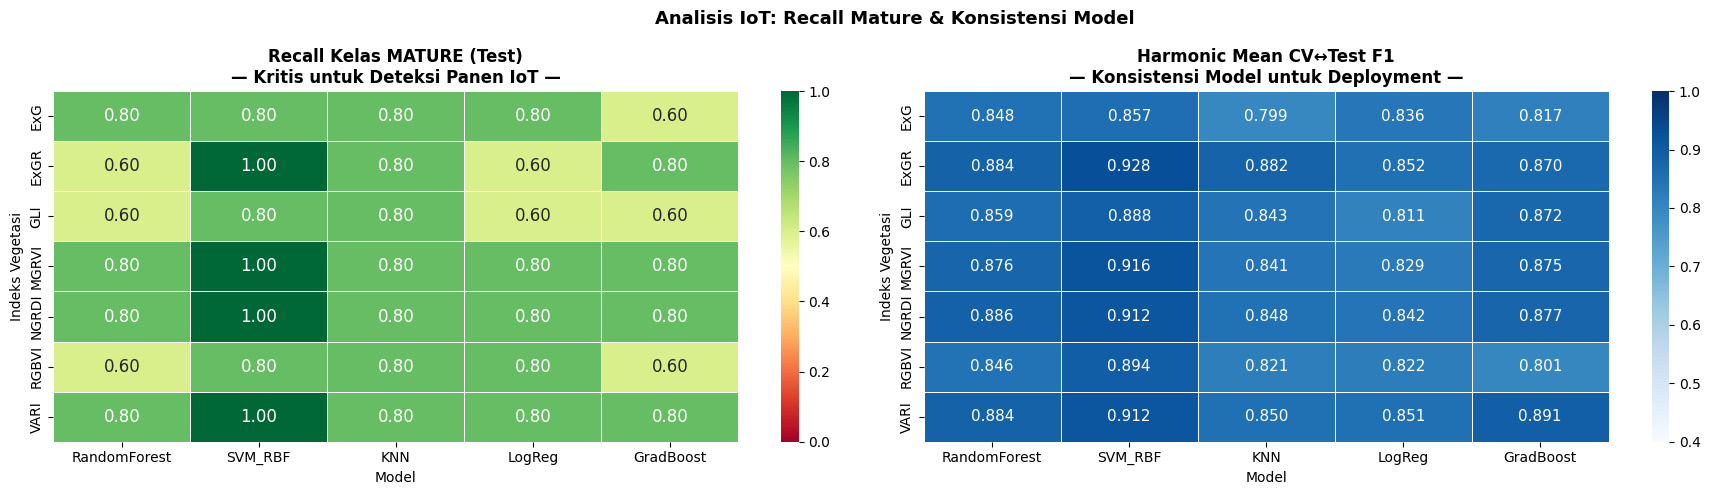


📱 Rekomendasi untuk IoT ESP32:
   VI    : ExGR
   Model : SVM_RBF
   Recall Mature  : 1.0000  (tidak melewatkan panen)
   CV F1-Macro    : 0.8901
   Test F1-Macro  : 0.9704
   HMean CV↔Test  : 0.9285

💡 Pipeline IoT:
   ESP32-CAM → foto RGB → server → hitung ExGR + GLCM → SVM_RBF → notifikasi


In [29]:
print("=" * 65)
print("  ANALISIS IoT — RECALL KELAS MATURE (Kritis untuk Panen)")
print("=" * 65)

mature_idx = list(le.classes_).index("Mature")

mature_recalls = []
for _, row in exp_df.iterrows():
    vi      = row["vi"]
    mod     = row["model"]
    vi_cols = [f"{vi}_{s}" for s in STAT_NAMES] + GLCM_NAMES

    X_tv_i = trainval_df[vi_cols].values
    X_te_i = test_df[vi_cols].values

    ros_i = RandomOverSampler(random_state=42)
    X_si, y_si = ros_i.fit_resample(X_tv_i, y_trainval)
    clf_i = get_models()[mod]
    clf_i.fit(X_si, y_si)
    pred_i = clf_i.predict(X_te_i)

    cm_i = confusion_matrix(y_test, pred_i)
    n_mature = cm_i[mature_idx].sum()
    recall_m = float(cm_i[mature_idx, mature_idx] / n_mature) if n_mature > 0 else 0.0

    mature_recalls.append({
        "vi": vi, "model": mod,
        "recall_mature":  round(recall_m, 4),
        "cv_f1_macro":    row["cv_f1_macro"],
        "test_f1_macro":  row["test_f1_macro"],
        "cv_test_hmean":  row["cv_test_hmean"],
    })

df_mature = (pd.DataFrame(mature_recalls)
             .sort_values(["recall_mature","cv_test_hmean"], ascending=False)
             .reset_index(drop=True))
df_mature.index += 1

print("\nTop 10 — Recall Mature tertinggi (IoT harvest detection):")
display(df_mature.head(10))

# Heatmap recall Mature
pivot_rm = pd.DataFrame(mature_recalls).pivot(
    index="vi", columns="model", values="recall_mature")[MODEL_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot_rm, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=axes[0], vmin=0.0, vmax=1.0, annot_kws={"size": 12})
axes[0].set_title("Recall Kelas MATURE (Test)\n— Kritis untuk Deteksi Panen IoT —",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Indeks Vegetasi")

pivot_hmean = exp_df.pivot(index="vi", columns="model", values="cv_test_hmean")[MODEL_NAMES]
sns.heatmap(pivot_hmean, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.5, ax=axes[1], vmin=0.4, vmax=1.0, annot_kws={"size": 11})
axes[1].set_title("Harmonic Mean CV↔Test F1\n— Konsistensi Model untuk Deployment —",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Indeks Vegetasi")

plt.suptitle("Analisis IoT: Recall Mature & Konsistensi Model",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Rekomendasi akhir
best_iot = df_mature.iloc[0]
print(f"\n📱 Rekomendasi untuk IoT ESP32:")
print(f"   VI    : {best_iot['vi']}")
print(f"   Model : {best_iot['model']}")
print(f"   Recall Mature  : {best_iot['recall_mature']:.4f}  (tidak melewatkan panen)")
print(f"   CV F1-Macro    : {best_iot['cv_f1_macro']:.4f}")
print(f"   Test F1-Macro  : {best_iot['test_f1_macro']:.4f}")
print(f"   HMean CV↔Test  : {best_iot['cv_test_hmean']:.4f}")
print(f"\n💡 Pipeline IoT:")
print(f"   ESP32-CAM → foto RGB → server → hitung {best_iot['vi']} + GLCM → {best_iot['model']} → notifikasi")


## 💾 Simpan Output

In [31]:
DRIVE_DIR = "/content/drive/MyDrive"

# Path lokal Colab
BEST_MODEL_PATH = f"/content/best_3class_{prac_vi}_{prac_model}.joblib"
ENC_PATH        = "/content/label_encoder_3class.joblib"

# Path Google Drive (bisa langsung download dari sini)
BEST_MODEL_DRIVE = f"{DRIVE_DIR}/best_3class_{prac_vi}_{prac_model}.joblib"
ENC_DRIVE        = f"{DRIVE_DIR}/label_encoder_3class.joblib"

joblib.dump(best_clf, BEST_MODEL_PATH)
joblib.dump(le,       ENC_PATH)
joblib.dump(best_clf, BEST_MODEL_DRIVE)
joblib.dump(le,       ENC_DRIVE)

print("Saved ke Colab  :", BEST_MODEL_PATH)
print("Saved ke Drive  :", BEST_MODEL_DRIVE)
print("Encoder ke Drive:", ENC_DRIVE)
print("CSV ke Drive    :", "/content/drive/MyDrive/features_3class.csv")
print(f"Nama file model : best_3class_{prac_vi}_{prac_model}.joblib")
print("Salin file .joblib dari Google Drive ke folder app.py")


Saved ke Colab  : /content/best_3class_ExGR_SVM_RBF.joblib
Saved ke Drive  : /content/drive/MyDrive/best_3class_ExGR_SVM_RBF.joblib
Encoder ke Drive: /content/drive/MyDrive/label_encoder_3class.joblib
CSV ke Drive    : /content/drive/MyDrive/features_3class.csv
Nama file model : best_3class_ExGR_SVM_RBF.joblib
Salin file .joblib dari Google Drive ke folder app.py


In [32]:
from google.colab import files
files.download(EXP_CSV)
files.download(BEST_MODEL_PATH)
files.download(ENC_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🤖 Fungsi Prediksi — 3 Kelas

In [33]:
def predict_image(image_path, vi_name=None, model_clf=None, label_encoder=None):
    """
    Prediksi fase pertumbuhan padi (3 kelas: Vegetative / Generative / Mature).
    Default pakai kombinasi VI + model terbaik dari eksperimen.
    """
    if vi_name is None:      vi_name      = best_vi
    if model_clf is None:    model_clf    = best_clf
    if label_encoder is None: label_encoder = le

    rgb = read_rgb(image_path)
    if rgb is None:
        raise ValueError(f"Gagal membaca: {image_path}")

    mask   = green_mask(rgb)
    vi_fn  = VI_REGISTRY[vi_name]
    vi_map = vi_fn(rgb)
    vi_use = vi_map[mask] if mask.mean() > 0.01 else vi_map.flatten()

    stats    = extract_vi_stats(vi_use)
    gray     = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    glcm     = compute_glcm_features(gray)
    vi_cols  = [f"{vi_name}_{s}" for s in STAT_NAMES] + GLCM_NAMES
    feat_vals = [stats[s] for s in STAT_NAMES] + [glcm[g] for g in GLCM_NAMES]

    X          = np.array([feat_vals], dtype=np.float32)
    pred_id    = model_clf.predict(X)[0]
    pred_label = label_encoder.inverse_transform([pred_id])[0]

    # Interpretasi untuk petani
    interpretasi = {
        "Vegetative": "🌱 Fase vegetatif — tanaman masih tumbuh, belum mendekati panen.",
        "Generative": "🌾 Fase generatif — bulir sedang berkembang, panen masih beberapa minggu.",
        "Mature":     "✅ Fase matang — padi siap dipanen!",
    }

    return {
        "prediksi":      pred_label,
        "interpretasi":  interpretasi[pred_label],
    }

# Test prediksi
example = test_df["path"].iloc[0]
result  = predict_image(example)
true    = test_df.iloc[0]["label"]

print(f"Gambar      : {os.path.basename(example)}")
print(f"True label  : {true}")
print(f"Prediksi    : {result['prediksi']}")
print(f"Keterangan  : {result['interpretasi']}")
print(f"{'✅ Benar' if result['prediksi'] == true else '❌ Salah'}")


Gambar      : IMG_3573_jpg.rf.0c3e87e1d0f470083f201d37d5f3354f.jpg
True label  : Generative
Prediksi    : Generative
Keterangan  : 🌾 Fase generatif — bulir sedang berkembang, panen masih beberapa minggu.
✅ Benar
